# Business Analytics II – Project II
### 2020120083 손영진

## 개요 (Overview)
이 프로젝트는 에어비앤비 호스트가 '슈퍼호스트'인지 예측하는 분류 모델을 구축합니다. building classification models to predict whether an Airbnb host is a "Superhost".
The process includes:
1. 데이터 전처리 (Data Preprocessing) (Handling missing values, Encoding, Balancing, Scaling)
2. 모델 구축 및 하이퍼파라미터 튜닝 (Logistic Regression, Decision Tree, Random Forest, MLP, KNN, Naive Bayes)
3. 최종 예측 (Final Prediction) on Test Data using the best model

In [ ]:
# Install requirements
!pip install -r requirements.txt


# 1. Import Libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree # Added plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score, ConfusionMatrixDisplay
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager') # Added specific filter for font warnings
warnings.filterwarnings('ignore') # Keep general ignore for other warnings

import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

# Explicitly set a generic font to avoid 'AppleGothic' warning
plt.rcParams['font.family'] = 'DejaVu Sans' # Or 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False # Ensure minus signs display correctly



In [2]:
# === 결과 저장 헬퍼 함수 ===
import os
from datetime import datetime

# 결과 저장 폴더 생성
OUTPUT_DIR = f"./results_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"📁 결과 저장 폴더: {OUTPUT_DIR}")

def save_figure(fig, name, dpi=150):
    """Figure를 SVG와 PNG로 저장"""
    svg_path = os.path.join(OUTPUT_DIR, f"{name}.svg")
    png_path = os.path.join(OUTPUT_DIR, f"{name}.png")
    fig.savefig(svg_path, format='svg', bbox_inches='tight')
    fig.savefig(png_path, format='png', dpi=dpi, bbox_inches='tight')
    print(f"💾 저장됨: {svg_path}")
    return svg_path

def save_dataframe(df, name):
    """DataFrame을 CSV로 저장"""
    csv_path = os.path.join(OUTPUT_DIR, f"{name}.csv")
    df.to_csv(csv_path, index=False)
    print(f"💾 저장됨: {csv_path}")
    return csv_path


📁 결과 저장 폴더: ./results_20251206_153427


# 2. Data Load

In [80]:
# Load datasets
train_path = 'train_data.csv'
test_path = 'test_f25.xlsx'

df_train = pd.read_csv(train_path)
df_test = pd.read_excel(test_path)

print(f"Train Shape: {df_train.shape}")
print(f"Test Shape: {df_test.shape}")
df_train.head()


Train Shape: (26304, 54)
Test Shape: (130, 55)


,estimated_revenue_l365d,last_review,calculated_host_listings_count_shared_rooms,review_scores_communication,review_scores_location,availability_60,host_listings_count,host_identity_verified,host_response_rate,number_of_reviews_l30d,...,reviews_per_month,maximum_minimum_nights,availability_30,beds,maximum_maximum_nights,host_response_time,has_availability,host_is_superhost,bedrooms,review_scores_value
0,13890.0,2024-10-19,0,4.94,4.94,52,8.0,t,80%,0,...,0.33,2,25,4.0,1125,within a day,t,f,3.0,4.85
1,0.0,NaN,0,NaN,NaN,0,7.0,t,NaN,0,...,NaN,4,0,5.0,730,NaN,t,f,3.0,NaN
2,0.0,2022-06-16,0,4.71,4.86,58,7.0,t,100%,0,...,0.05,14,29,2.0,1125,within a few hours,t,f,1.0,5.00
3,0.0,2016-04-15,0,5.00,5.00,60,2.0,t,NaN,0,...,0.01,14,30,1.0,30,NaN,t,NaN,1.0,4.00
4,NaN,NaN,0,NaN,NaN,0,1.0,f,NaN,0,...,NaN,3,0,NaN,730,NaN,NaN,f,2.0,NaN


# 3. 데이터 전처리 (Data Preprocessing)

먼저 타겟 변수가 없는 것들은 드랍

In [4]:
# Target Variable
target_col = 'host_is_superhost'

# Convert target to binary (t/f -> 1/0)
df_train[target_col] = df_train[target_col].map({'t': 1, 'f': 0})

# Check for missing values in target and drop them
df_train = df_train.dropna(subset=[target_col])
print(f"Train Shape after dropping missing targets: {df_train.shape}")

# Separate Target and Features
y = df_train[target_col]
X = df_train.drop(columns=[target_col])

# Drop columns that are entirely empty (all NaNs)
X = X.dropna(axis=1, how='all')


Train Shape after dropping missing targets: (25386, 54)


날짜 변수는 계산할 수 있는 연속형 수치 변수로 변환

In [5]:
# --- Date Processing ---
print("Processing Dates...")
date_cols = ['last_review', 'first_review','calendar_last_scraped']
for col in date_cols:
    if col in X.columns:
        # Convert to datetime
        X[col] = pd.to_datetime(X[col], errors='coerce')
        if col in df_test.columns:
            df_test[col] = pd.to_datetime(df_test[col], errors='coerce')

        # Create 'days_since' feature (relative to a reference date, e.g., today or max date)
        ref_date = pd.Timestamp('2024-12-01') # Use a fixed recent date
        X[f'days_since_{col}'] = (ref_date - X[col]).dt.days
        df_test[f'days_since_{col}'] = (ref_date - df_test[col]).dt.days

        # Drop original date columns
        X = X.drop(columns=[col])
        df_test = df_test.drop(columns=[col])

X[[f'days_since_{col}' for col in date_cols if f'days_since_{col}' in X.columns]].head()


Processing Dates...


,days_since_last_review,days_since_first_review,days_since_calendar_last_scraped
0,43.0,4004.0,-209
1,NaN,NaN,-210
2,899.0,4347.0,-207
4,NaN,NaN,-212
5,830.0,5283.0,-208


가격도 연속형 수치 변수로

In [6]:
# --- Price Column Cleaning ---
# Remove '$' and ',' and convert to float
if 'price' in X.columns:
    X['price'] = X['price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
if 'price' in df_test.columns:
    df_test['price'] = df_test['price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

print("Price column converted to numerical.")


Price column converted to numerical.


퍼센트도

In [7]:
# --- Rate Columns Cleaning ---
rate_cols = ['host_acceptance_rate', 'host_response_rate']
for col in rate_cols:
    if col in X.columns:
        X[col] = X[col].astype(str).str.replace('%', '').astype(float)
    if col in df_test.columns:
        df_test[col] = df_test[col].astype(str).str.replace('%', '').astype(float)

print("Rate columns converted to numerical.")

Rate columns converted to numerical.



📊 Column: host_identity_verified
고유값 개수: 2

[Top 20 분포 테이블]
host_identity_verified
t      22633
f       1937
NaN      816
Name: count, dtype: int64


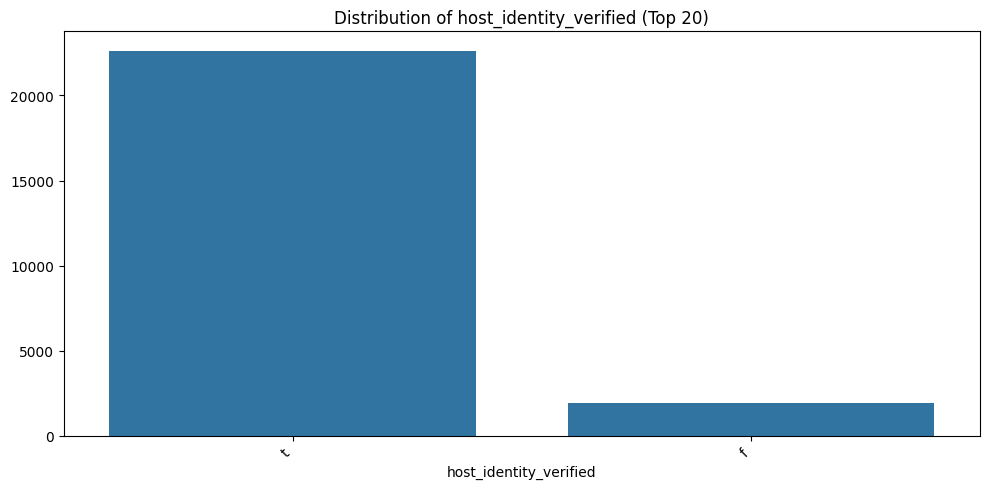


📊 Column: host_has_profile_pic
고유값 개수: 2

[Top 20 분포 테이블]
host_has_profile_pic
t      23813
NaN      816
f        757
Name: count, dtype: int64


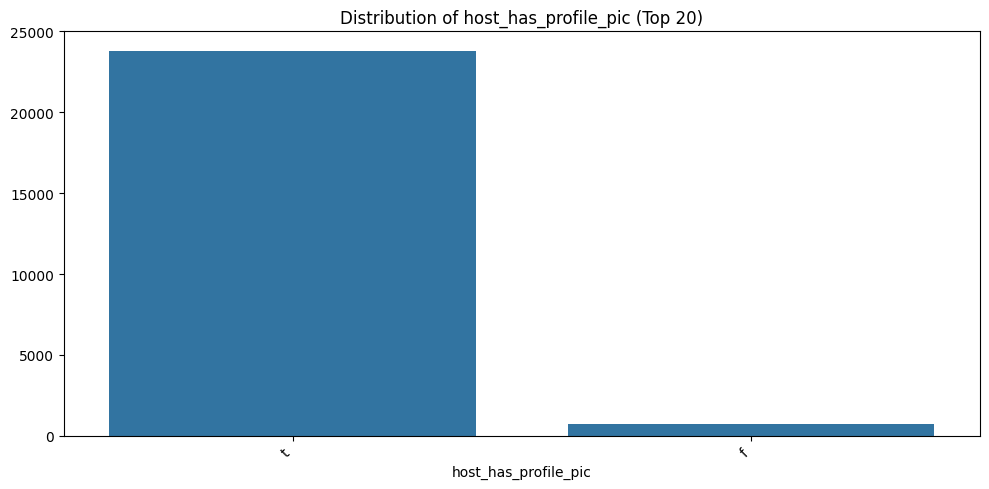


📊 Column: instant_bookable
고유값 개수: 2

[Top 20 분포 테이블]
instant_bookable
f    18231
t     7155
Name: count, dtype: int64


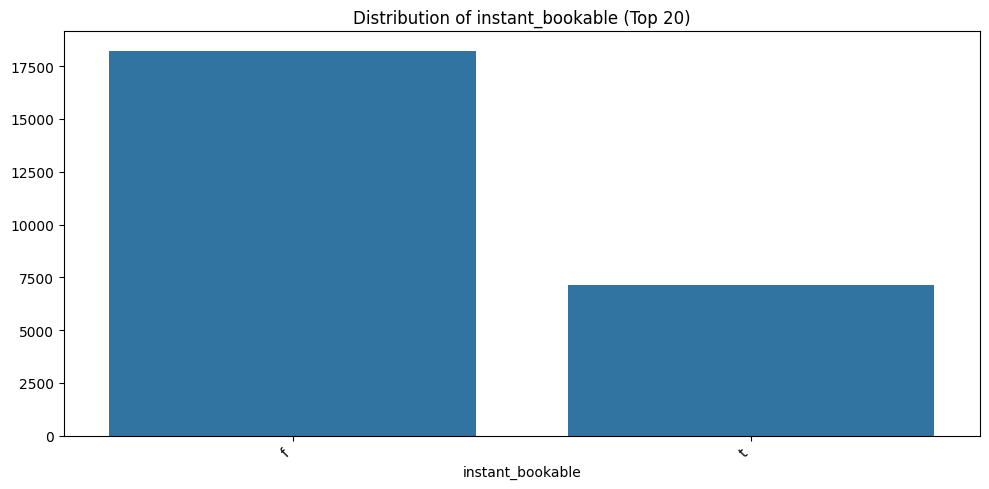


📊 Column: amenities
고유값 개수: 24481

[Top 20 분포 테이블]
amenities
["First aid kit", "Wifi", "Dedicated workspace", "Pool table", "Fire extinguisher"]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              65
[]                                                                                                                                                                                                                                                                                                                                                                                    

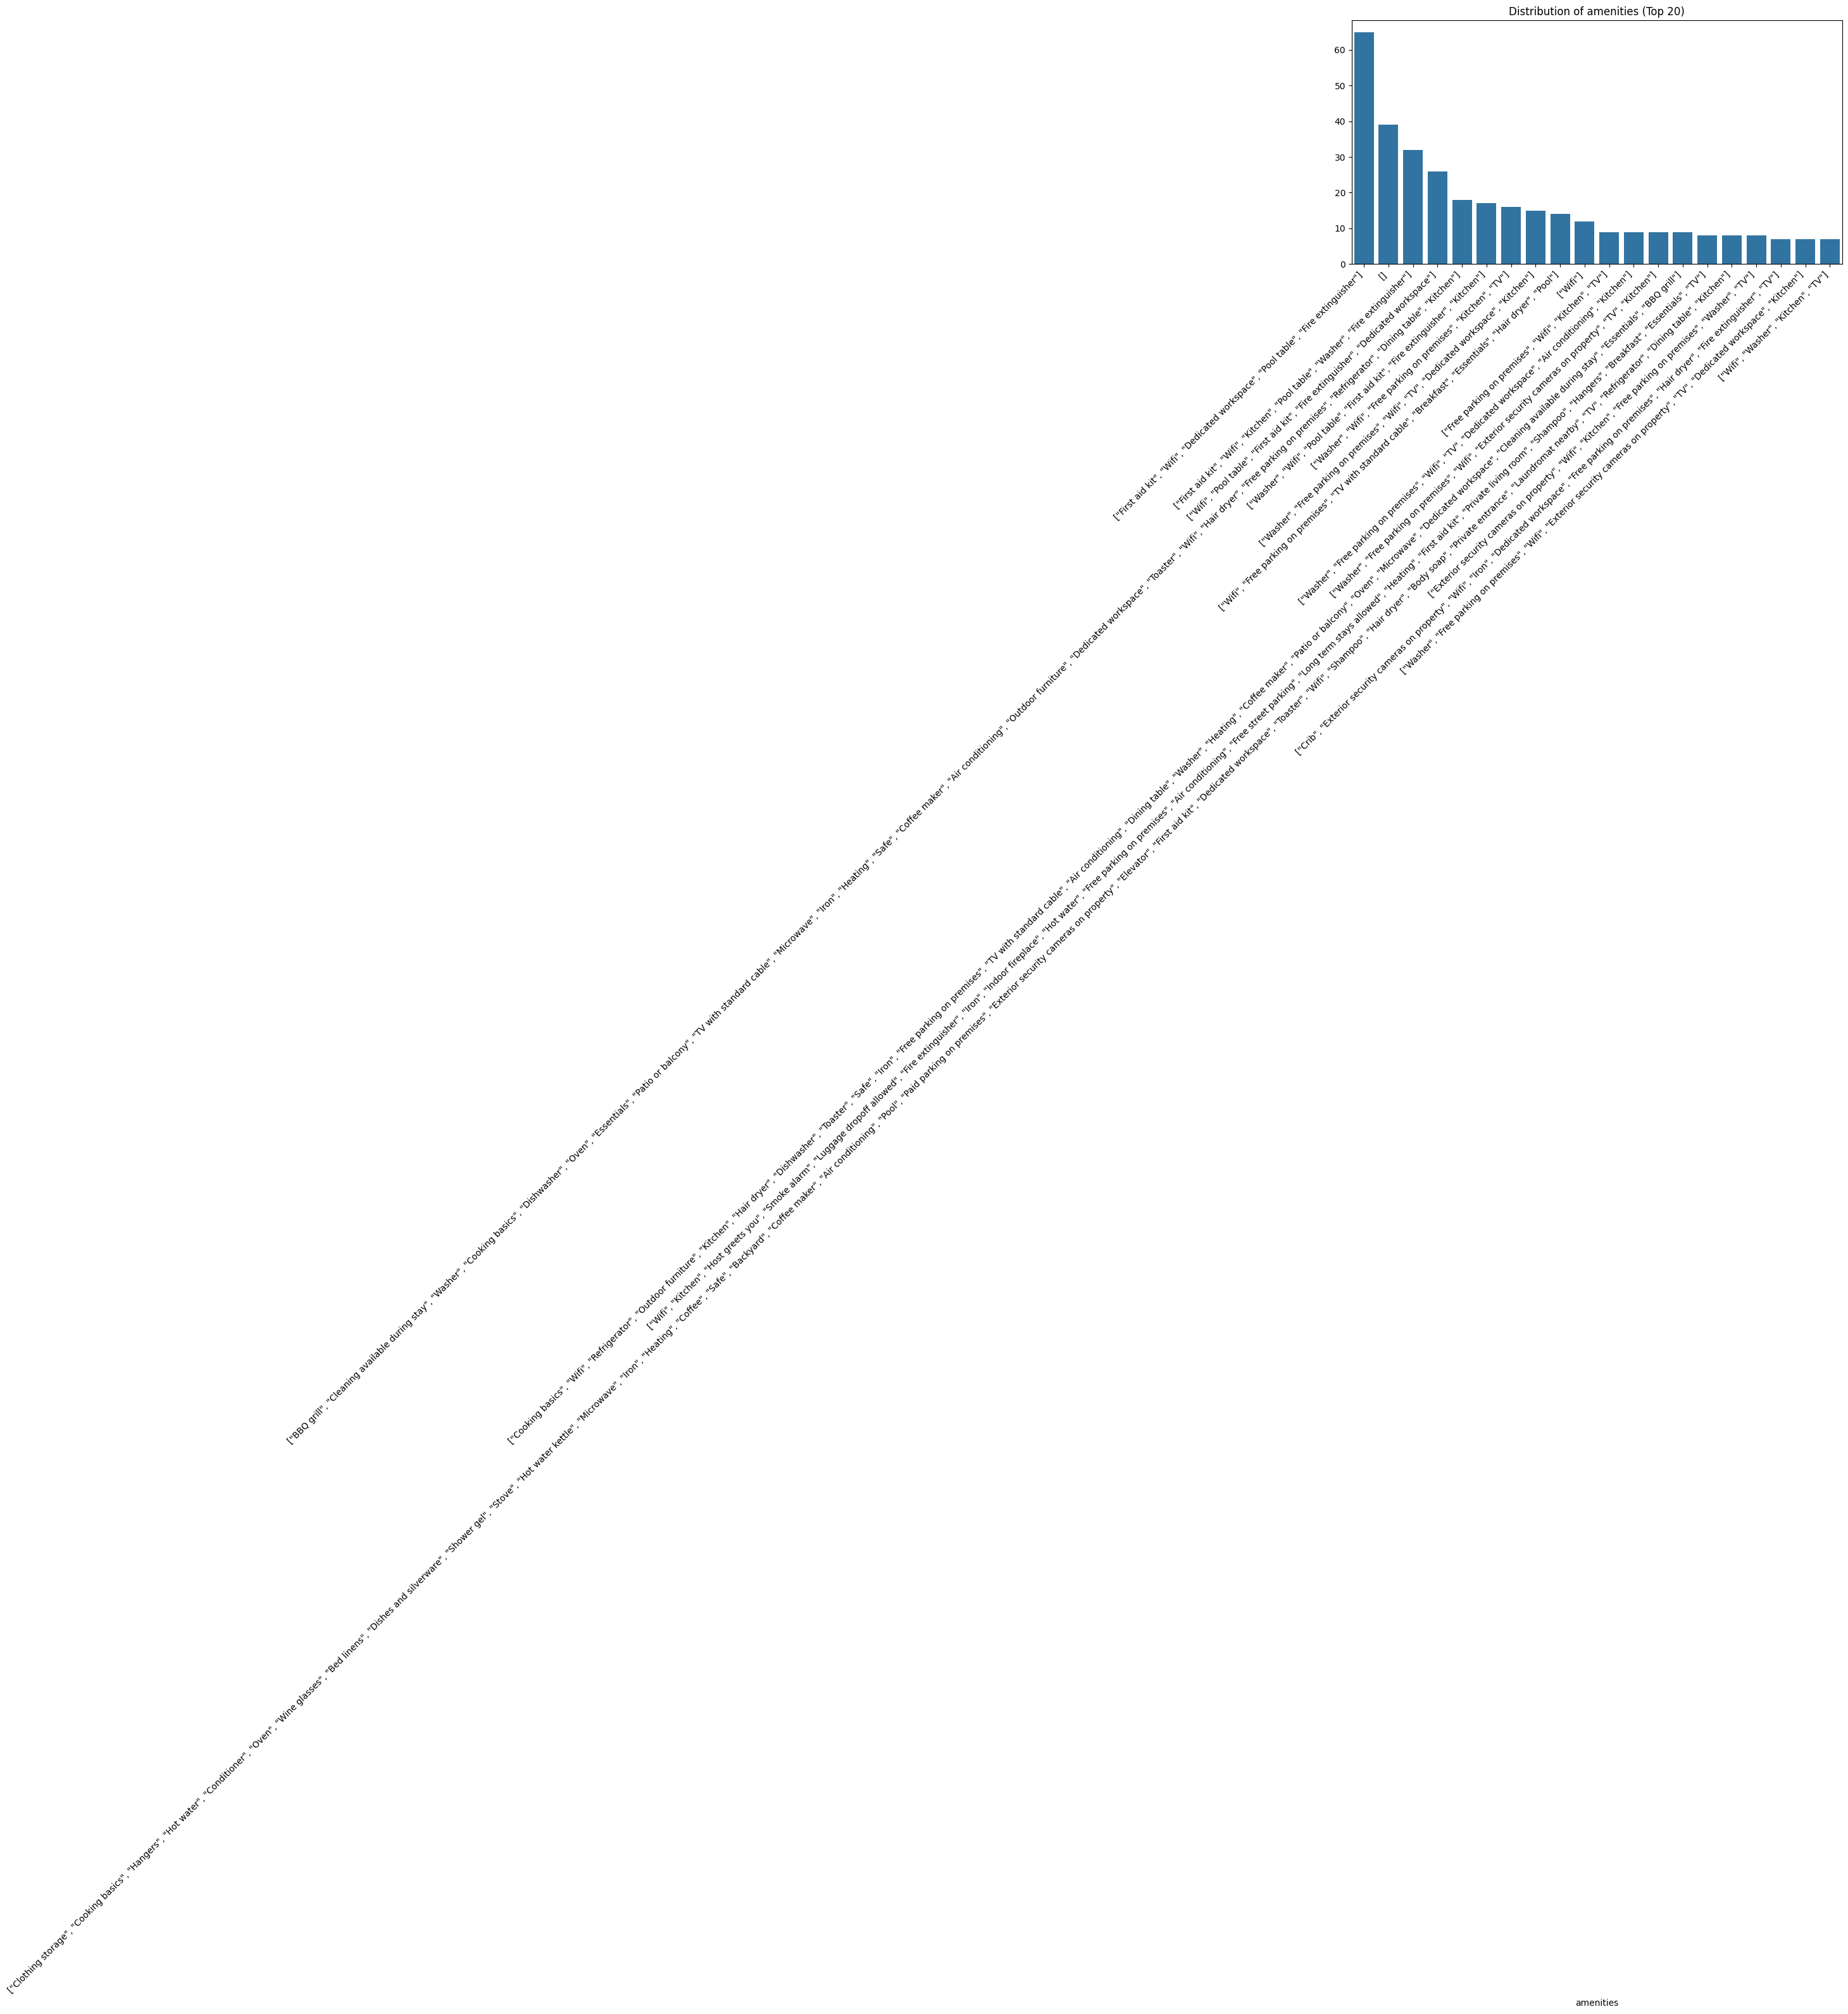


📊 Column: bathrooms_text
고유값 개수: 55

[Top 20 분포 테이블]
bathrooms_text
1 bath               11043
2 baths               4729
1 private bath        2152
1.5 baths             1299
3 baths               1248
2.5 baths             1041
3.5 baths              775
1 shared bath          665
4 baths                474
4.5 baths              334
1.5 shared baths       286
NaN                    213
5 baths                204
5.5 baths              128
Half-bath               91
2 shared baths          90
6 baths                 85
0 baths                 84
Private half-bath       80
6.5 baths               52
Name: count, dtype: int64
... 외 35개 더 있음


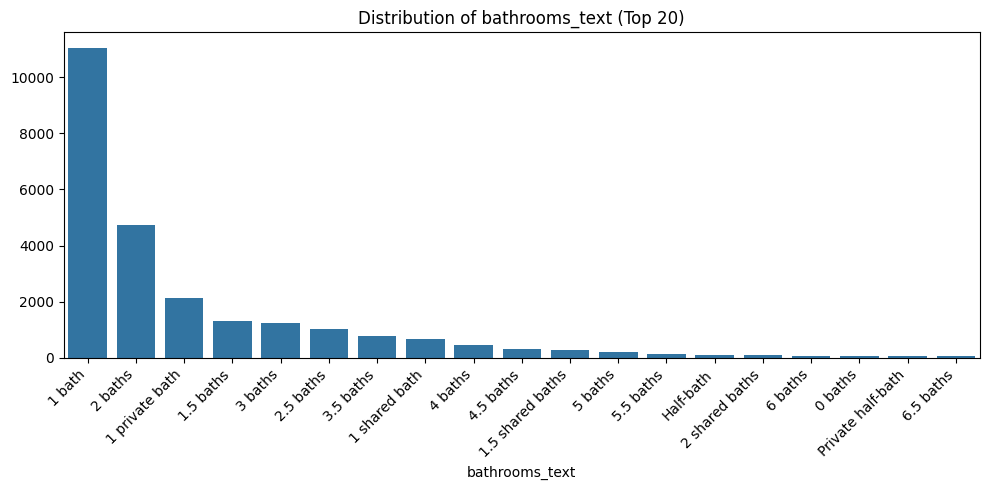


📊 Column: property_type
고유값 개수: 76

[Top 20 분포 테이블]
property_type
Entire rental unit                   10575
Entire home                           5211
Private room in home                  1554
Entire condo                          1112
Entire guest suite                     976
Private room in guesthouse             891
Entire villa                           768
Private room in rental unit            648
Entire guesthouse                      514
Entire serviced apartment              433
Private room in bed and breakfast      365
Entire cottage                         328
Room in hotel                          257
Private room in guest suite            231
Entire townhouse                       225
Entire loft                            195
Room in boutique hotel                 157
Private room in villa                   87
Entire vacation home                    81
Tiny home                               75
Name: count, dtype: int64
... 외 56개 더 있음


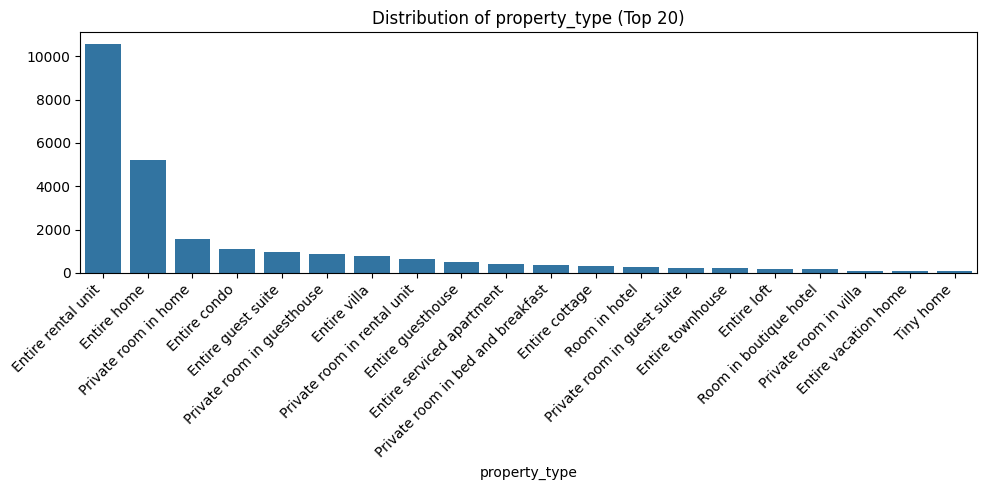


📊 Column: room_type
고유값 개수: 4

[Top 20 분포 테이블]
room_type
Entire home/apt    20776
Private room        4464
Hotel room           113
Shared room           33
Name: count, dtype: int64


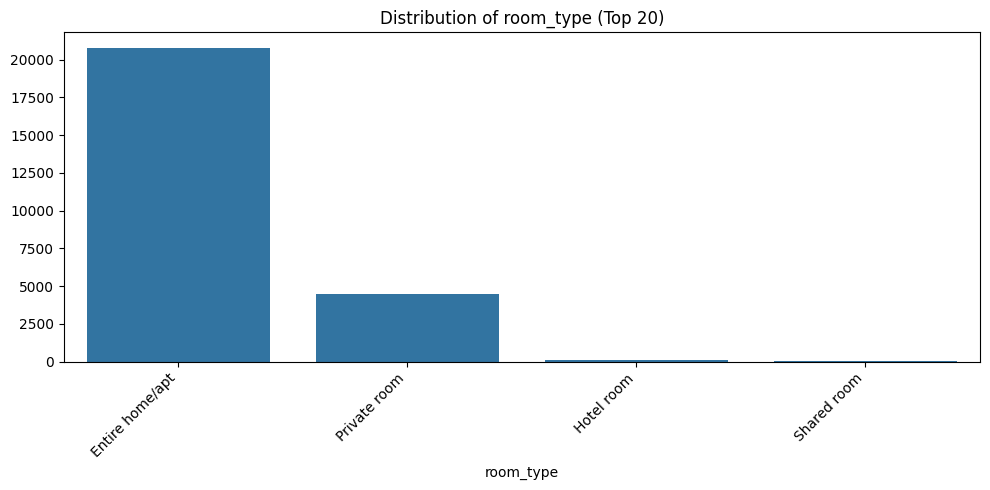


📊 Column: host_response_time
고유값 개수: 4

[Top 20 분포 테이블]
host_response_time
within an hour        12716
NaN                    7617
within a few hours     2903
within a day           1600
a few days or more      550
Name: count, dtype: int64


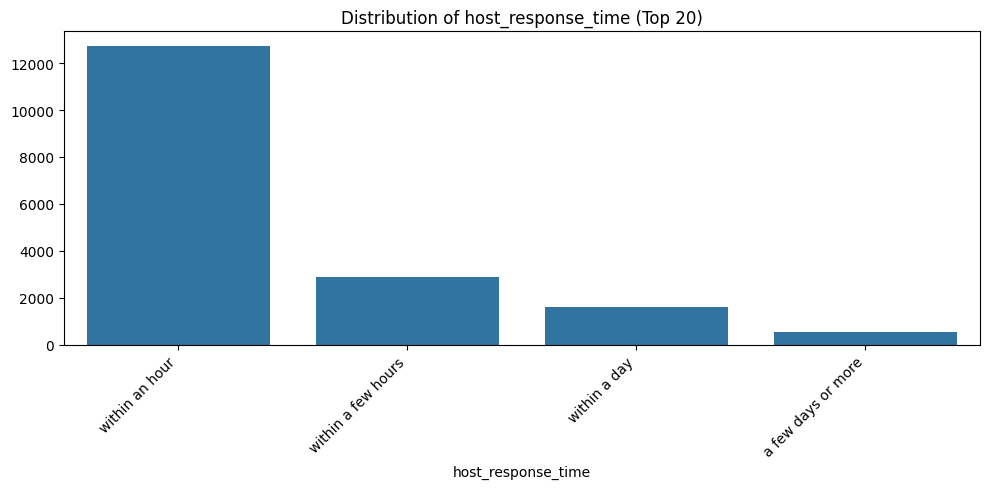


📊 Column: has_availability
고유값 개수: 1

[Top 20 분포 테이블]
has_availability
t      23915
NaN     1471
Name: count, dtype: int64


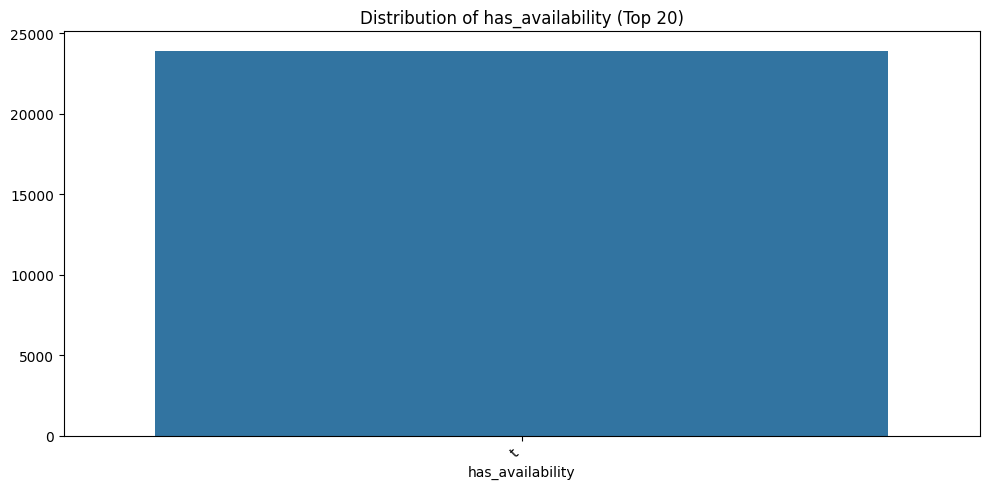

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 분석할 카테고리형 변수만 선택
target_df = X
cat_cols = target_df.select_dtypes(include=['object']).columns

# 한글 폰트 설정 (필요시 - 맥에서는 AppleGothic 등)
plt.rcParams['font.family'] = 'DejaVu Sans'

for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"📊 Column: {col}")
    print(f"{'='*50}")

    # 1. 값의 종류 개수(Unique Count) 확인
    unique_cnt = target_df[col].nunique()
    print(f"고유값 개수: {unique_cnt}")

    # 2. 분포 테이블 (Top 20만 출력, 나머지는 생략)
    val_counts = target_df[col].value_counts(dropna=False)
    print("\n[Top 20 분포 테이블]")
    print(val_counts.head(20))
    if unique_cnt > 20:
        print(f"... 외 {unique_cnt - 20}개 더 있음")

    # 3. 그래프 그리기 (상위 20개만 시각화)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=val_counts.head(20).index, y=val_counts.head(20).values)
    plt.title(f"Distribution of {col} (Top 20)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [9]:
import re

# ============================================
# 1. host_has_profile_pic: NaN → 'f'
# ============================================
X['host_has_profile_pic'] = X['host_has_profile_pic'].fillna('f')
df_test['host_has_profile_pic'] = df_test['host_has_profile_pic'].fillna('f')
print("✅ host_has_profile_pic: NaN → 'f' 완료")


# ============================================
# 2. bathrooms_text → bathrooms_count + is_shared_bath
# ============================================
def parse_bathrooms(text):
    """숫자 추출 + shared 여부 판단"""
    if pd.isna(text):
        return np.nan, 0  # NaN은 나중에 median으로 채움

    text = str(text).lower()

    # shared 여부
    is_shared = 1 if 'shared' in text else 0

    # 숫자 추출 (예: "1.5 baths" → 1.5, "Half-bath" → 0.5)
    if 'half' in text:
        num = 0.5
    else:
        match = re.search(r'(\d+\.?\d*)', text)
        num = float(match.group(1)) if match else np.nan

    return num, is_shared

# 적용
X['bathrooms_count'], X['is_shared_bath'] = zip(*X['bathrooms_text'].apply(parse_bathrooms))
df_test['bathrooms_count'], df_test['is_shared_bath'] = zip(*df_test['bathrooms_text'].apply(parse_bathrooms))

# 결측치는 median으로
median_bath = X['bathrooms_count'].median()
X['bathrooms_count'] = X['bathrooms_count'].fillna(median_bath)
df_test['bathrooms_count'] = df_test['bathrooms_count'].fillna(median_bath)

# 원본 컬럼 삭제
X = X.drop(columns=['bathrooms_text'])
df_test = df_test.drop(columns=['bathrooms_text'])
print(f"✅ bathrooms_text → bathrooms_count (median={median_bath}), is_shared_bath 완료")


# ============================================
# 3. host_response_time: NaN → 'Unknown'
# ============================================
X['host_response_time'] = X['host_response_time'].fillna('Unknown')
df_test['host_response_time'] = df_test['host_response_time'].fillna('Unknown')
print("✅ host_response_time: NaN → 'Unknown' 완료")

✅ host_has_profile_pic: NaN → 'f' 완료
✅ bathrooms_text → bathrooms_count (median=1.0), is_shared_bath 완료
✅ host_response_time: NaN → 'Unknown' 완료


In [10]:
# ============================================
# 4. property_type: 유사 타입 군집화 (임베딩 기반)
# ============================================
# 이건 SentenceTransformer 이용해서 임베딩 → 클러스터링 후 그룹 라벨 부여
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

# 고유 property_type 목록
unique_types = X['property_type'].dropna().unique().tolist()
print(f"property_type 고유값: {len(unique_types)}개")

# 임베딩 생성
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
type_embeddings = embed_model.encode(unique_types)

# KMeans 군집화 (10~15개 그룹으로 줄이기)
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(type_embeddings)

# 매핑 딕셔너리 생성
type_to_cluster = {t: f"property_group_{cluster_labels[i]}" for i, t in enumerate(unique_types)}

# 적용
X['property_type'] = X['property_type'].map(type_to_cluster).fillna('property_group_other')
df_test['property_type'] = df_test['property_type'].map(type_to_cluster).fillna('property_group_other')

print(f"✅ property_type: {len(unique_types)}개 → {n_clusters}개 그룹으로 군집화 완료")
print("군집 분포:")
print(X['property_type'].value_counts())

property_type 고유값: 76개


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ property_type: 76개 → 6개 그룹으로 군집화 완료
군집 분포:
property_type
property_group_0    20622
property_group_4     3949
property_group_5      612
property_group_2      118
property_group_3       54
property_group_1       31
Name: count, dtype: int64


=== 클러스터별 property_type 목록 ===

🏷️ Cluster 0 (18개):
   - Entire home
   - Entire rental unit
   - Entire guest suite
   - Entire villa
   - Entire guesthouse
   - Entire loft
   - Entire place
   - Entire condo
   - Entire cottage
   - Entire serviced apartment
   - Entire townhouse
   - Entire bungalow
   - Entire cabin
   - Entire chalet
   - Entire vacation home
   - Entire resort
   - Casa particular
   - Entire home/apt

🏷️ Cluster 1 (9개):
   - Tower
   - Hut
   - Camper/RV
   - Dome
   - Shipping container
   - Barn
   - Shepherd’s hut
   - Cave
   - Tent

🏷️ Cluster 2 (5개):
   - Tiny home
   - Earthen home
   - Farm stay
   - Treehouse
   - Houseboat

🏷️ Cluster 3 (10개):
   - Shared room in condo
   - Room in aparthotel
   - Shared room in rental unit
   - Shared room in home
   - Shared room in loft
   - Shared room in boutique hotel
   - Shared room in dome
   - Shared room in hostel
   - Shared room in hotel
   - Shared room in guesthouse

🏷️ Cluster 4 (24개):
   - Private roo

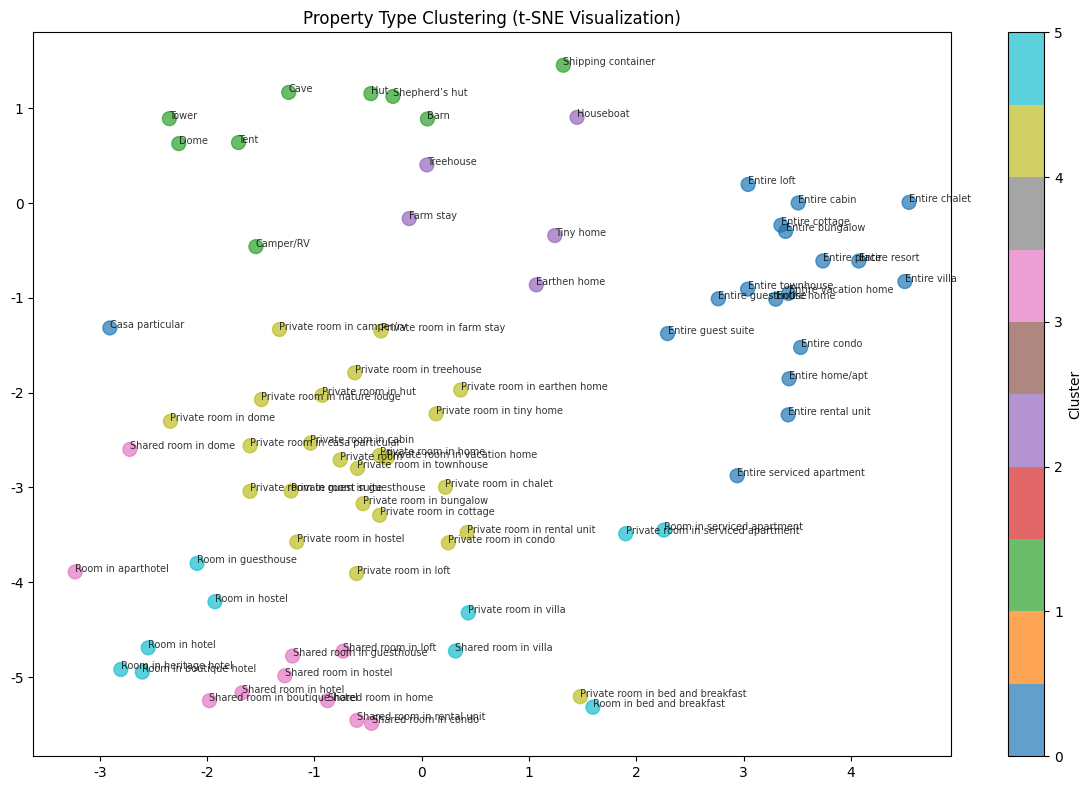

In [11]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# --- 클러스터별 멤버 출력 ---
print("=== 클러스터별 property_type 목록 ===")
cluster_df = pd.DataFrame({'type': unique_types, 'cluster': cluster_labels})
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['type'].tolist()
    print(f"\n🏷️ Cluster {c} ({len(members)}개):")
    for m in members:
        print(f"   - {m}")

# --- t-SNE로 2D 시각화 ---
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(unique_types)-1))
embeddings_2d = tsne.fit_transform(type_embeddings)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=cluster_labels, cmap='tab10', s=100, alpha=0.7)
plt.colorbar(scatter, label='Cluster')

# 각 점에 라벨 달기
for i, txt in enumerate(unique_types):
    plt.annotate(txt, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=7, alpha=0.8)

plt.title("Property Type Clustering (t-SNE Visualization)")
plt.tight_layout()
plt.show()

In [12]:
# 수동 보정
manual_override = {
    'Private room in villa': 4,
    'Private room in serviced apartment': 4,
    'Shared room in villa': 3,
}

# type_to_cluster 딕셔너리 업데이트
for prop_type, new_cluster in manual_override.items():
    if prop_type in type_to_cluster:
        type_to_cluster[prop_type] = new_cluster

print("✅ 수동 보정 완료")

✅ 수동 보정 완료


| 클러스터 | 의미 |
|---|---|
| 0 | Entire Place (전체 숙소) |
| 1 | Unique Outdoor (동굴, 텐트, 캠핑카 등) |
| 2 | Eco/Alternative (트리하우스, 타이니홈) |
| 3 | Shared Room |
| 4 | Private Room |
| 5 | Hotel/Hostel Room |

어메니티 텍스트도 범주형으로 처리하지 않고 그냥 한번에 임베딩해버림

In [13]:
# --- Text Embedding (Amenities) ---
print("Embedding Amenities (this may take a while)...")
if 'amenities' in X.columns:
    # Load pre-trained model
    model = SentenceTransformer('all-MiniLM-L6-v2')

    # Fill NaNs with empty string
    X['amenities'] = X['amenities'].fillna('')
    df_test['amenities'] = df_test['amenities'].fillna('')

    # Encode
    train_embeddings = model.encode(X['amenities'].tolist(), show_progress_bar=True)
    test_embeddings = model.encode(df_test['amenities'].tolist(), show_progress_bar=True)

    # Create DataFrame from embeddings
    embedding_cols = [f'amenity_emb_{i}' for i in range(train_embeddings.shape[1])]
    train_emb_df = pd.DataFrame(train_embeddings, columns=embedding_cols, index=X.index)
    test_emb_df = pd.DataFrame(test_embeddings, columns=embedding_cols, index=df_test.index)

    # Concatenate and drop original column
    X = pd.concat([X, train_emb_df], axis=1).drop(columns=['amenities'])
    df_test = pd.concat([df_test, test_emb_df], axis=1).drop(columns=['amenities'])

# Identify categorical and numerical columns (Refresh after new features)
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

print(f"Categorical Columns: {len(cat_cols)}")
print(f"Numerical Columns: {len(num_cols)}")

Embedding Amenities (this may take a while)...


Batches:   0%|          | 0/794 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Categorical Columns: 7
Numerical Columns: 45


In [14]:
# Handle Missing Values
# For numerical, fill with median
for col in num_cols:
    median_val = X[col].median()  # Calculate median on Train
    X[col] = X[col].fillna(median_val)
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(median_val)  # Apply Train median to Test

# For categorical, fill with mode
for col in cat_cols:
    mode_val = X[col].mode()[0]  # Calculate mode on Train
    X[col] = X[col].fillna(mode_val)
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(mode_val)  # Apply Train mode to Test


In [15]:
# One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
df_test_encoded = pd.get_dummies(df_test, columns=cat_cols, drop_first=True)

# Align columns (Ensure train and test have same features)
X_encoded, df_test_encoded = X_encoded.align(df_test_encoded, join='left', axis=1, fill_value=0)

print(f"Encoded Train Features Shape: {X_encoded.shape}")
print(f"Encoded Test Features Shape: {df_test_encoded.shape}")


Encoded Train Features Shape: (25386, 444)
Encoded Test Features Shape: (130, 444)


In [16]:
# --- 범주형 변수 고유값 분석 (Dimensionality Explosion Check) ---
print(f"{'Column Name':<30} | {'Unique Values':<15} | {'Example Values (Top 3)'}")
print("-" * 80)

# 차원 증가에 가장 큰 영향을 미치는 순서대로 정렬하여 출력
for col in X[cat_cols].nunique().sort_values(ascending=False).index:
    unique_count = X[col].nunique()
    top_values = X[col].value_counts().head(3).index.tolist()
    print(f"{col:<30} | {unique_count:<15} | {top_values}")

print("-" * 80)
print(f"Total new columns created (approx): {X[cat_cols].nunique().sum() - len(cat_cols)}")

Column Name                    | Unique Values   | Example Values (Top 3)
--------------------------------------------------------------------------------
property_type                  | 6               | ['property_group_0', 'property_group_4', 'property_group_5']
host_response_time             | 5               | ['within an hour', 'Unknown', 'within a few hours']
room_type                      | 4               | ['Entire home/apt', 'Private room', 'Hotel room']
instant_bookable               | 2               | ['f', 't']
host_has_profile_pic           | 2               | ['t', 'f']
host_identity_verified         | 2               | ['t', 'f']
has_availability               | 1               | ['t']
--------------------------------------------------------------------------------
Total new columns created (approx): 15


In [17]:
# --- Potential Numerical Columns Detection ---
print(f"{'Column Name':<30} | {'Sample Values (Top 3)':<40} | {'Potential Type'}")
print("-" * 90)

potential_num_cols = []

for col in X.select_dtypes(include=['object']).columns:
    # 샘플 데이터 3개 가져오기
    sample_values = X[col].dropna().head(3).tolist()

    # 숫자 변환 시도 ($, %, , 제거 후)
    try:
        # 1. 순수 숫자인지 확인
        pd.to_numeric(X[col].dropna())
        is_numeric = True
        note = "Numeric (Clean)"
    except:
        # 2. 특수문자($, %, ,) 제거 후 숫자인지 확인
        try:
            clean_series = X[col].astype(str).str.replace(r'[$,%]', '', regex=True)
            pd.to_numeric(clean_series)
            is_numeric = True
            note = "Numeric (Needs Cleaning: $, %)"
        except:
            is_numeric = False
            note = "Categorical"

    if is_numeric:
        print(f"{col:<30} | {str(sample_values):<40} | {note}")
        potential_num_cols.append(col)

print("-" * 90)
if not potential_num_cols:
    print("No hidden numerical columns found.")
else:
    print(f"Found {len(potential_num_cols)} columns that look like numbers but are Object type.")

Column Name                    | Sample Values (Top 3)                    | Potential Type
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
No hidden numerical columns found.


### 클래스 불균형 처리 (Class Imbalance Handling)
데이터의 클래스 비율을 맞추기 위해 리샘플링(Resampling)을 수행합니다.
- **옵션**: `SAMPLING_METHOD`를 `'upsample'`(업샘플링) 또는 `'downsample'`(다운샘플링)로 설정할 수 있습니다.
- **업샘플링 (Upsampling)**: 소수 클래스 데이터를 복제하여 늘립니다. 정보 손실이 없지만 과적합(Overfitting) 위험이 있습니다.
- **다운샘플링 (Downsampling)**: 다수 클래스 데이터를 줄여서 맞춥니다. 학습 속도는 빠르지만 중요한 정보가 손실될 수 있습니다.

## 5. 특성 스케일링 (Feature Scaling)

In [18]:
SAMPLING_METHOD = 'upsample'  # Options: 'upsample', 'downsample'

# First, split the data into training and validation sets
# The validation set should not be affected by resampling
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print("Original Training Class Distribution (before resampling):")
print(y_train_raw.value_counts())

# Combine X_train_raw and y_train_raw for resampling
train_data_resample = pd.concat([X_train_raw, y_train_raw], axis=1)

# Separate majority and minority classes within the training data
df_majority = train_data_resample[train_data_resample[target_col] == 0]
df_minority = train_data_resample[train_data_resample[target_col] == 1]

if SAMPLING_METHOD == 'upsample':
    print("\nPerforming Upsampling on Training Data...")
    df_minority_upsampled = resample(df_minority,
                                     replace=True,     # sample with replacement
                                     n_samples=len(df_majority),    # to match majority class
                                     random_state=42)
    df_train_balanced = pd.concat([df_majority, df_minority_upsampled])

elif SAMPLING_METHOD == 'downsample':
    print("\nPerforming Downsampling on Training Data...")
    df_majority_downsampled = resample(df_majority,
                                       replace=False,    # sample without replacement
                                       n_samples=len(df_minority),    # to match minority class
                                       random_state=42)
    df_train_balanced = pd.concat([df_majority_downsampled, df_minority])
else:
    # No resampling
    df_train_balanced = train_data_resample

# Display new class counts for training data
print("\nBalanced Training Class Distribution:")
print(df_train_balanced[target_col].value_counts())

# Separate X and y again for the balanced training set
X_train_balanced = df_train_balanced.drop(columns=[target_col])
y_train_balanced = df_train_balanced[target_col]

# --- Feature Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_val_scaled = scaler.transform(X_val_raw) # Scale validation data using the same scaler fitted on training data
X_test_scaled = scaler.transform(df_test_encoded) # Scale test data

# Convert scaled arrays back to DataFrames, preserving column names
X_train = pd.DataFrame(X_train_scaled, columns=X_train_balanced.columns, index=X_train_balanced.index)
X_val = pd.DataFrame(X_val_scaled, columns=X_val_raw.columns, index=X_val_raw.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=df_test_encoded.columns, index=df_test_encoded.index)

# Assign y_train and y_val for consistency with subsequent cells
y_train = y_train_balanced
y_val = y_val_raw

print(f"\nTraining Set Shape (after resampling and scaling): {X_train.shape}")
print(f"Validation Set Shape (after scaling): {X_val.shape}")
print(f"Test Set Shape (after scaling): {X_test_scaled.shape}")


Original Training Class Distribution (before resampling):
host_is_superhost
0.0    13731
1.0     6577
Name: count, dtype: int64

Performing Upsampling on Training Data...

Balanced Training Class Distribution:
host_is_superhost
0.0    13731
1.0    13731
Name: count, dtype: int64

Training Set Shape (after resampling and scaling): (27462, 444)
Validation Set Shape (after scaling): (5078, 444)
Test Set Shape (after scaling): (130, 444)


### 하이퍼파라미터 튜닝 전략 (Hyperparameter Tuning Strategy)
`GridSearchCV`를 사용하여 각 모델의 최적 하이퍼파라미터를 찾습니다. 각 매개변수의 선정 이유는 다음과 같습니다.

- **MLP (신경망)**:
    - `hidden_layer_sizes`: 모델의 복잡도를 결정합니다. `(50,)`은 단순 모델, `(50, 50)`은 더 깊은 패턴을 학습합니다.
    - `activation`: `relu`는 일반적인 딥러닝 활성화 함수이며, `tanh`도 테스트합니다.
    - `alpha`: 과적합을 막기 위한 규제 파라미터입니다.

- **Random Forest & Decision Tree**:
    - `max_depth`: 트리의 깊이입니다. 너무 깊으면 과적합될 수 있어 제한을 둡니다.
    - `min_samples_split`: 노드를 분할하기 위한 최소 샘플 수입니다. 클수록 일반화에 유리합니다.

- **KNN**:
    - `n_neighbors`: 이웃의 수입니다. 작으면 노이즈에 민감하고, 크면 너무 단순해질 수 있습니다.
    - `weights`: `distance`는 가까운 이웃에게 더 큰 가중치를 줍니다.

- **Logistic Regression**:
    - `C`: 규제 강도의 역수입니다. 작을수록 규제가 강해져 과적합을 막습니다.

In [19]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def visualize_model_result(name, model, X, y):
    print(f"\n=== Visualizing Results for {name} ===")

    # 1. Confusion Matrix
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Superhost', 'Superhost'])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'{name} - Confusion Matrix')
    try:
        fig = plt.gcf()
        save_figure(fig, f'{name}_plot')
    except: pass
    plt.show()

    # 2. ROC & Precision-Recall Curves (if probability is supported)
    if hasattr(model, 'predict_proba'):
        try:
            y_proba = model.predict_proba(X)[:, 1]

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

            # ROC Curve
            fpr, tpr, _ = roc_curve(y, y_proba)
            roc_auc = auc(fpr, tpr)
            ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
            ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            ax1.set_xlim([0.0, 1.0])
            ax1.set_ylim([0.0, 1.05])
            ax1.set_xlabel('False Positive Rate')
            ax1.set_ylabel('True Positive Rate')
            ax1.set_title(f'{name} - ROC Curve')
            ax1.legend(loc="lower right")

            # Precision-Recall Curve
            precision, recall, _ = precision_recall_curve(y, y_proba)
            avg_precision = average_precision_score(y, y_proba)
            ax2.plot(recall, precision, color='green', lw=2, label=f'AP = {avg_precision:.2f}')
            ax2.set_xlabel('Recall')
            ax2.set_ylabel('Precision')
            ax2.set_title(f'{name} - Precision-Recall Curve')
            ax2.legend(loc="lower left")

            plt.tight_layout()
            try:
                fig = plt.gcf()
                save_figure(fig, f'{name}_plot')
            except: pass
            plt.show()
        except Exception as e:
            print(f"Could not plot ROC/PR curves: {e}")

    # 3. Model Specific Visualizations

    # FEATURE IMPORTANCE (Random Forest, Decision Tree, GBM, etc.)
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        # Show Top 40 features to see more detail
        indices = np.argsort(importances)[::-1][:40]

        plt.figure(figsize=(12, 8))
        plt.title(f'{name} - Top 40 Feature Importance')
        plt.bar(range(len(indices)), importances[indices], align='center')
        plt.xticks(range(len(indices)), [X.columns[i] for i in indices], rotation=90, fontsize=9)
        plt.tight_layout()
        try:
            fig = plt.gcf()
            save_figure(fig, f'{name}_plot')
        except: pass
        plt.show()

    # COEFFICIENTS (Linear Models: Logistic Regression, Linear SVM)
    if hasattr(model, 'coef_'):
        coefs = model.coef_[0]
        # Show Top 20 Positive and Top 20 Negative coefficients
        indices_pos = np.argsort(coefs)[::-1][:20]
        indices_neg = np.argsort(coefs)[:20]

        # Combine and sort for display
        indices = np.concatenate([indices_pos, indices_neg])
        # Create a dataframe for plotting
        coef_data = pd.DataFrame({'Feature': [X.columns[i] for i in indices], 'Coefficient': coefs[indices]})
        coef_data = coef_data.sort_values(by='Coefficient', ascending=False)

        plt.figure(figsize=(12, 8))
        plt.title(f'{name} - Top Positive & Negative Coefficients')
        sns.barplot(x='Feature', y='Coefficient', data=coef_data, palette='coolwarm')
        plt.xticks(rotation=90, fontsize=9)
        plt.axhline(0, color='black', linewidth=0.8)
        plt.tight_layout()
        try:
            fig = plt.gcf()
            save_figure(fig, f'{name}_plot')
        except: pass
        plt.show()

    # LOSS CURVE (Neural Networks)
    if hasattr(model, 'loss_curve_'):
        plt.figure(figsize=(8, 5))
        plt.plot(model.loss_curve_)
        plt.title(f'{name} - Loss Curve')
        plt.xlabel('Iterations')
        plt.ylabel('Loss')
        try:
            fig = plt.gcf()
            save_figure(fig, f'{name}_plot')
        except: pass
        plt.show()

    # DECISION TREE STRUCTURE (Visualizing the Logic)
    if isinstance(model, DecisionTreeClassifier):
        print(f"{name} tree depth: {model.get_depth()}")
        plt.figure(figsize=(20, 10))  # Larger figure
        # Increased depth to 5 for more detail
        plot_tree(model, max_depth=5, feature_names=X.columns, class_names=['Not Superhost', 'Superhost'], filled=True, fontsize=8, proportion=True)
        plt.title(f'{name} - Tree Structure (Top 5 Levels)')
        try:
            fig = plt.gcf()
            save_figure(fig, f'{name}_plot')
        except: pass
        plt.show()


In [20]:
best_models = {}
results = []

*   **LogisticRegression**
    *   `C`: `[0.1, 1, 10]` → 정규화 강도의 역수. 작을수록 강한 정규화(과적합 방지), 클수록 약한 정규화. 보통 이 범위가 대부분의 케이스를 커버함.
    *   `solver`: `['liblinear']` → 작은~중간 크기 데이터셋에 효율적이고, L1/L2 정규화 모두 지원.
*   **DecisionTree**
    *   `max_depth`: `[5, 10, None]` → 트리 깊이 제한. `None`은 무제한이라 과적합 위험, 5~10은 적절한 일반화와 해석력 제공.
    *   `min_samples_split`: `[2, 5, 10]` → 분할에 필요한 최소 샘플 수. 값이 클수록 과적합 방지.
*   **RandomForest**
    *   `n_estimators`: `[50, 100]` → 트리 개수. 많으면 좋지만 학습 시간 증가. 50~100이 속도와 성능의 균형점.
    *   `max_depth`: `[10, None]` → DecisionTree와 동일 이유.
    *   `min_samples_leaf`: `[1, 2]` → 리프 노드 최소 샘플 수. 과적합 조절.
*   **MLP (Neural Network)**
    *   `hidden_layer_sizes`: `[(50,), (100,), (50, 25)]` → 단층(50, 100 뉴런) vs 2층(50→25) 네트워크 비교.
    *   `activation`: `['relu', 'tanh']` → 가장 일반적인 활성화 함수들.
    *   `alpha`: `[0.0001, 0.001]` → L2 정규화 강도. 과적합 방지용.
*   **KNN**
    *   `n_neighbors`: `[3, 5, 7]` → 이웃 개수. 작으면 과적합, 크면 과소적합. 홀수로 tie 방지.
    *   `weights`: `['uniform', 'distance']` → 모든 이웃 동등 vs 거리 기반 가중치.
*   **GaussianNB**
    *   `var_smoothing`: `[1e-9, 1e-8, 1e-7]` → 분산에 더해지는 안정화 상수. 0에 가까운 분산으로 인한 수치 불안정 방지.

--- Processing Logistic Regression ---
Fitting 5 folds for each of 3 candidates, totalling 15 fits
  Best Score: 0.8021
  Best Params: {'C': 0.1, 'solver': 'liblinear'}
  Recall: 0.8254
  F1 Score: 0.7247

=== Visualizing Results for Logistic Regression ===
💾 저장됨: ./results_20251206_153427/Logistic Regression_plot.svg


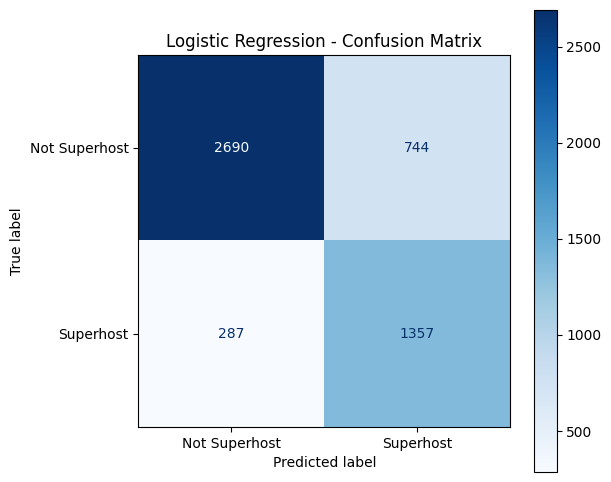

💾 저장됨: ./results_20251206_153427/Logistic Regression_plot.svg


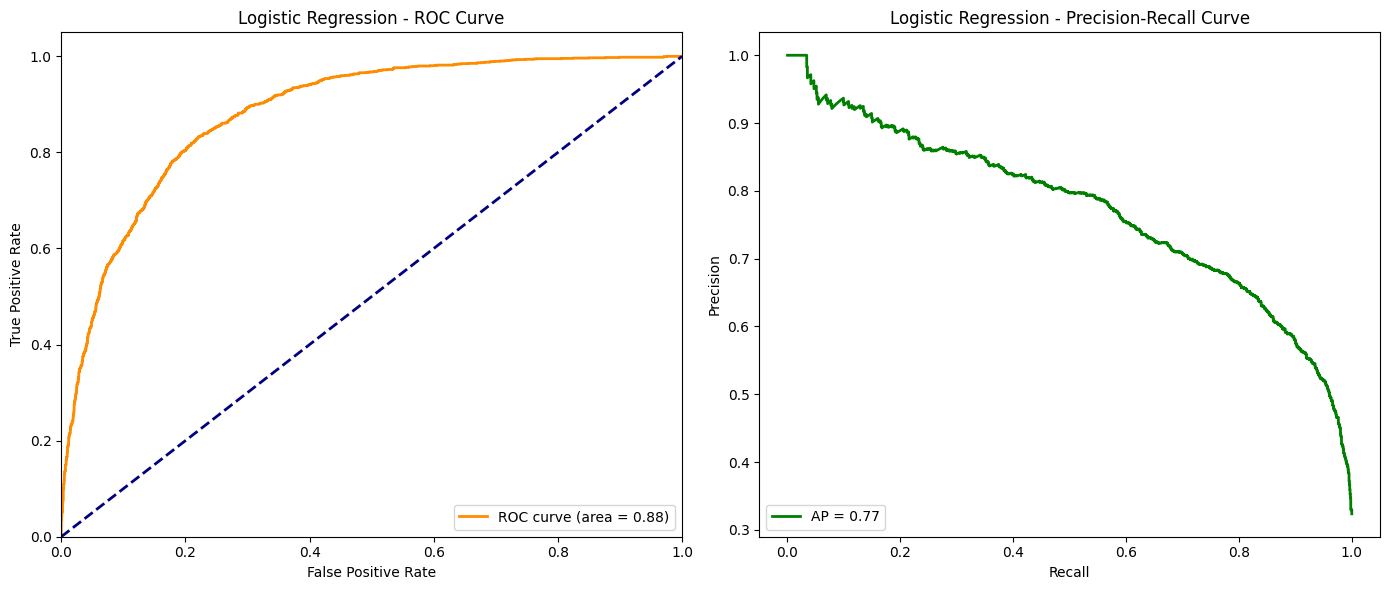

💾 저장됨: ./results_20251206_153427/Logistic Regression_plot.svg


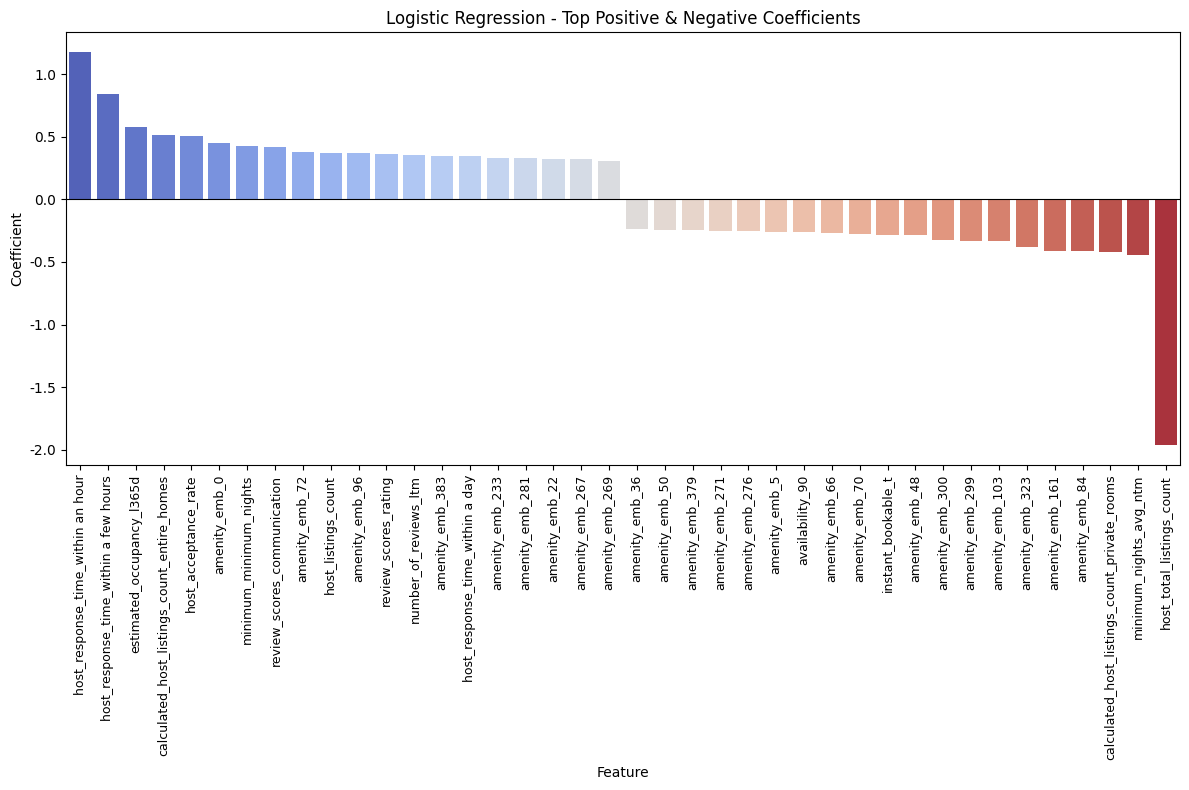

💾 저장됨: ./results_20251206_153427/LogisticRegression_cv_results.csv


In [26]:
print("--- Processing Logistic Regression ---")
lr_params = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}
clf = GridSearchCV(LogisticRegression(max_iter=100, random_state=42), lr_params, cv=5, scoring=['accuracy', 'recall', 'f1'], refit='f1', n_jobs=-1, verbose=3)
clf.fit(X_train, y_train)

# Calculate additional metrics
y_pred = clf.best_estimator_.predict(X_val)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)


best_models['Logistic Regression'] = clf.best_estimator_
results.append({
    'Model': 'Logistic Regression',
    'Best Score': clf.best_score_,
    'Best Params': clf.best_params_,
        'Recall': rec,
        'F1 Score': f1
})
print(f"  Best Score: {clf.best_score_:.4f}")
print(f"  Best Params: {clf.best_params_}")
print(f"  Recall: {rec:.4f}")
print(f"  F1 Score: {f1:.4f}")


# 결과 시각화
visualize_model_result('Logistic Regression', clf.best_estimator_, X_val, y_val)
# 결과 저장
try:
    import pandas as pd
    result_df = pd.DataFrame(clf.cv_results_)
    save_dataframe(result_df, 'LogisticRegression_cv_results')
except Exception as e:
    print(f"Save error: {e}")

--- Processing Decision Tree ---
Fitting 5 folds for each of 9 candidates, totalling 45 fits
  Best Score: 0.8944
  Best Params: {'max_depth': None, 'min_samples_split': 2}
  Recall: 0.6618
  F1 Score: 0.6775

=== Visualizing Results for Decision Tree ===
💾 저장됨: ./results_20251206_153427/Decision Tree_plot.svg


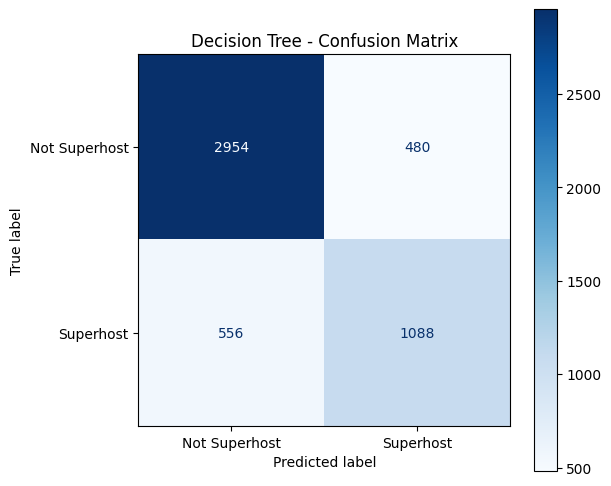

💾 저장됨: ./results_20251206_153427/Decision Tree_plot.svg


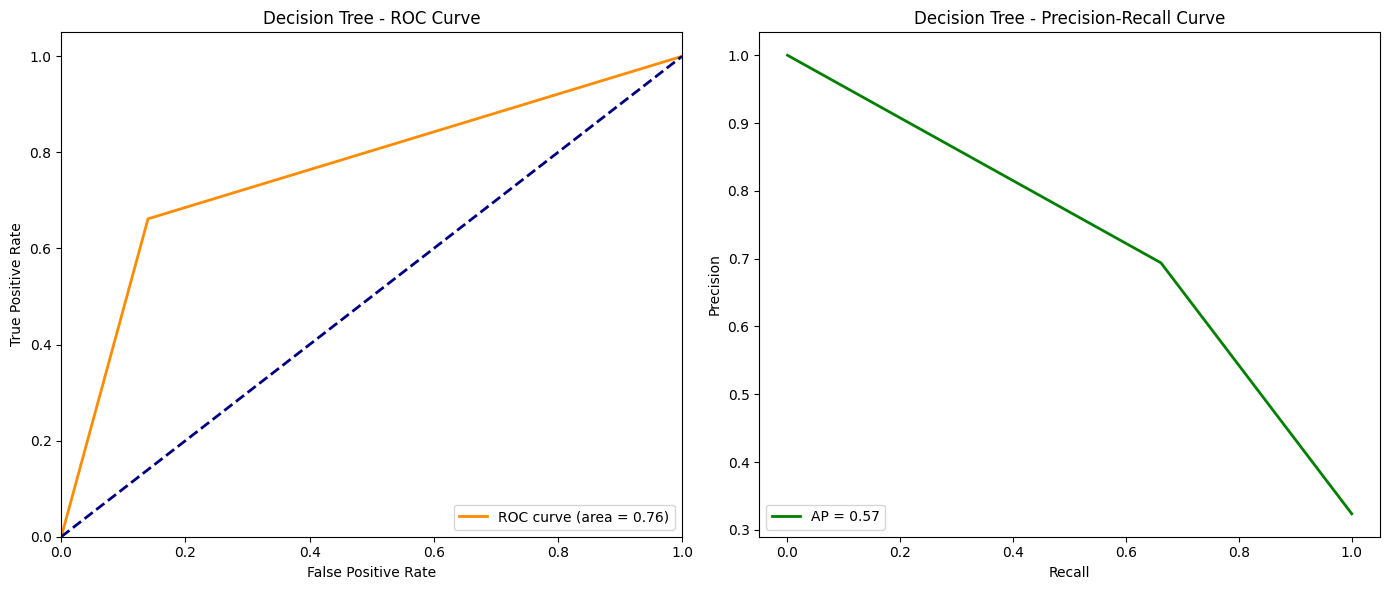

💾 저장됨: ./results_20251206_153427/Decision Tree_plot.svg


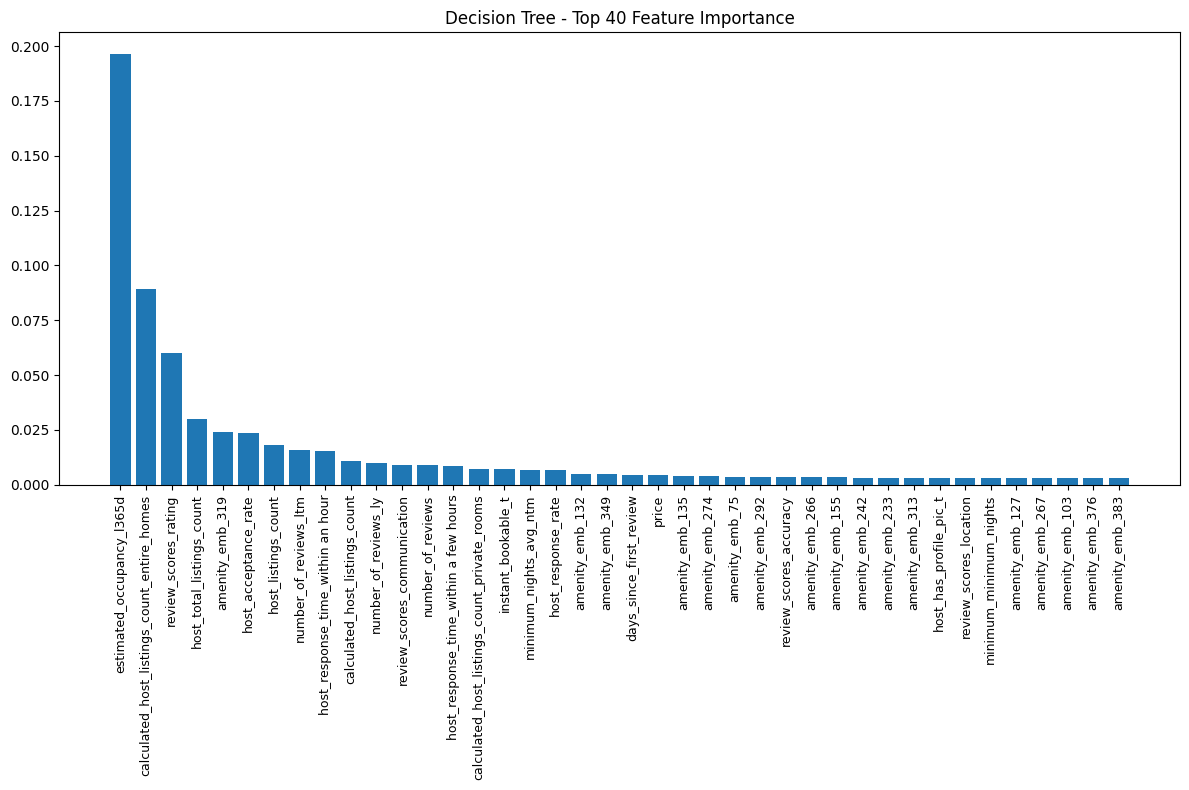

Decision Tree tree depth: 67
💾 저장됨: ./results_20251206_153427/Decision Tree_plot.svg


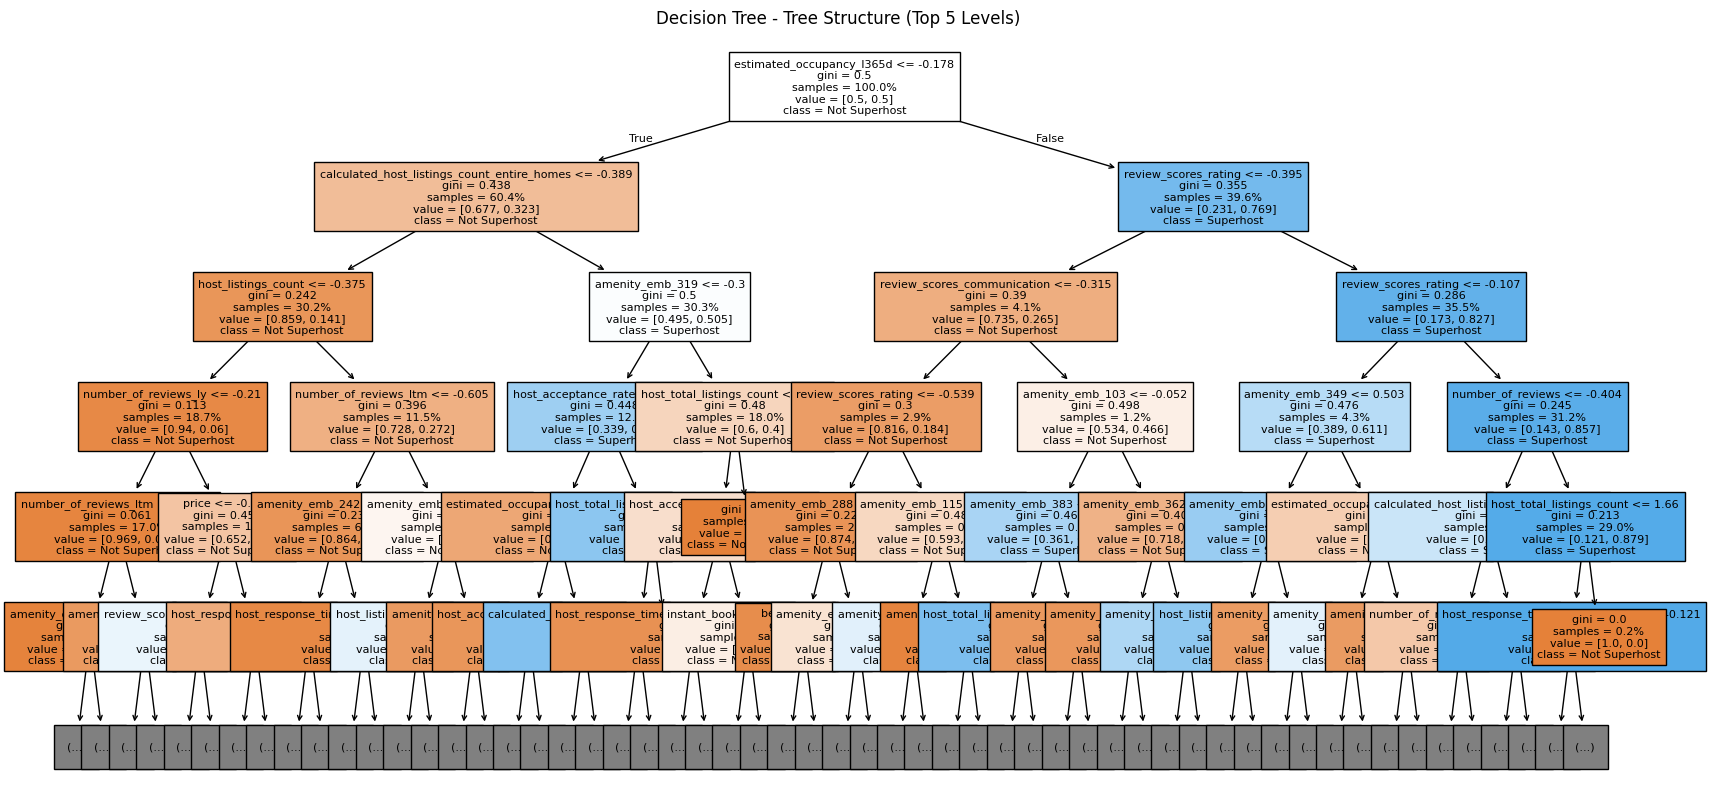

💾 저장됨: ./results_20251206_153427/DecisionTree_cv_results.csv


In [27]:
print("--- Processing Decision Tree ---")
dt_params = {
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}
clf = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring=['accuracy', 'recall', 'f1'], refit='f1', n_jobs=-1, verbose=3)
clf.fit(X_train, y_train)
# Calculate additional metrics
y_pred = clf.best_estimator_.predict(X_val)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)


best_models['Decision Tree'] = clf.best_estimator_
results.append({
    'Model': 'Decision Tree',
    'Best Score': clf.best_score_,
    'Best Params': clf.best_params_,
        'Recall': rec,
        'F1 Score': f1
})
print(f"  Best Score: {clf.best_score_:.4f}")
print(f"  Best Params: {clf.best_params_}")
print(f"  Recall: {rec:.4f}")
print(f"  F1 Score: {f1:.4f}")
    # 결과 시각화
visualize_model_result('Decision Tree', clf.best_estimator_, X_val, y_val)
# 결과 저장
try:
    import pandas as pd
    result_df = pd.DataFrame(clf.cv_results_)
    save_dataframe(result_df, 'DecisionTree_cv_results')
except Exception as e:
    print(f"Save error: {e}")

--- Processing Random Forest ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Best Score: 0.9300
  Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
  Recall: 0.6752
  F1 Score: 0.7356

=== Visualizing Results for Random Forest ===
💾 저장됨: ./results_20251206_153427/Random Forest_plot.svg


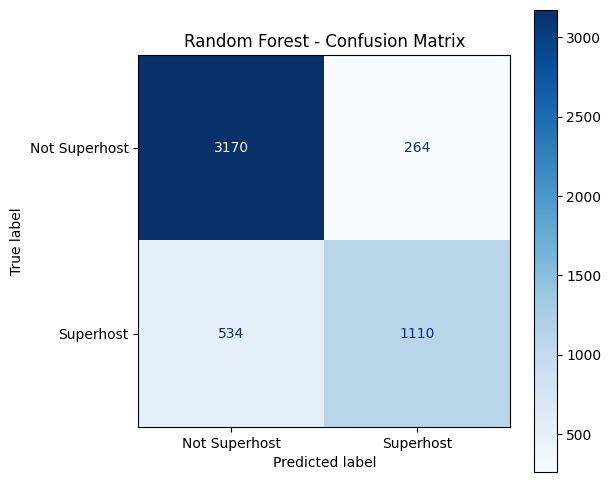

💾 저장됨: ./results_20251206_153427/Random Forest_plot.svg


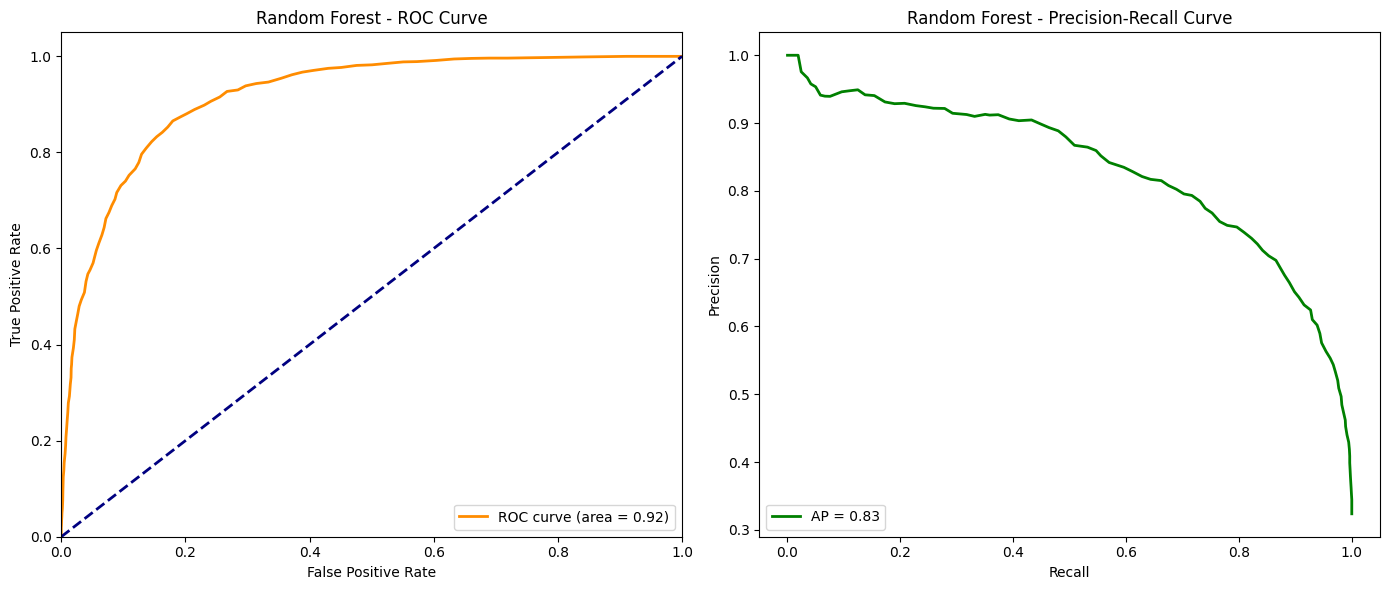

💾 저장됨: ./results_20251206_153427/Random Forest_plot.svg


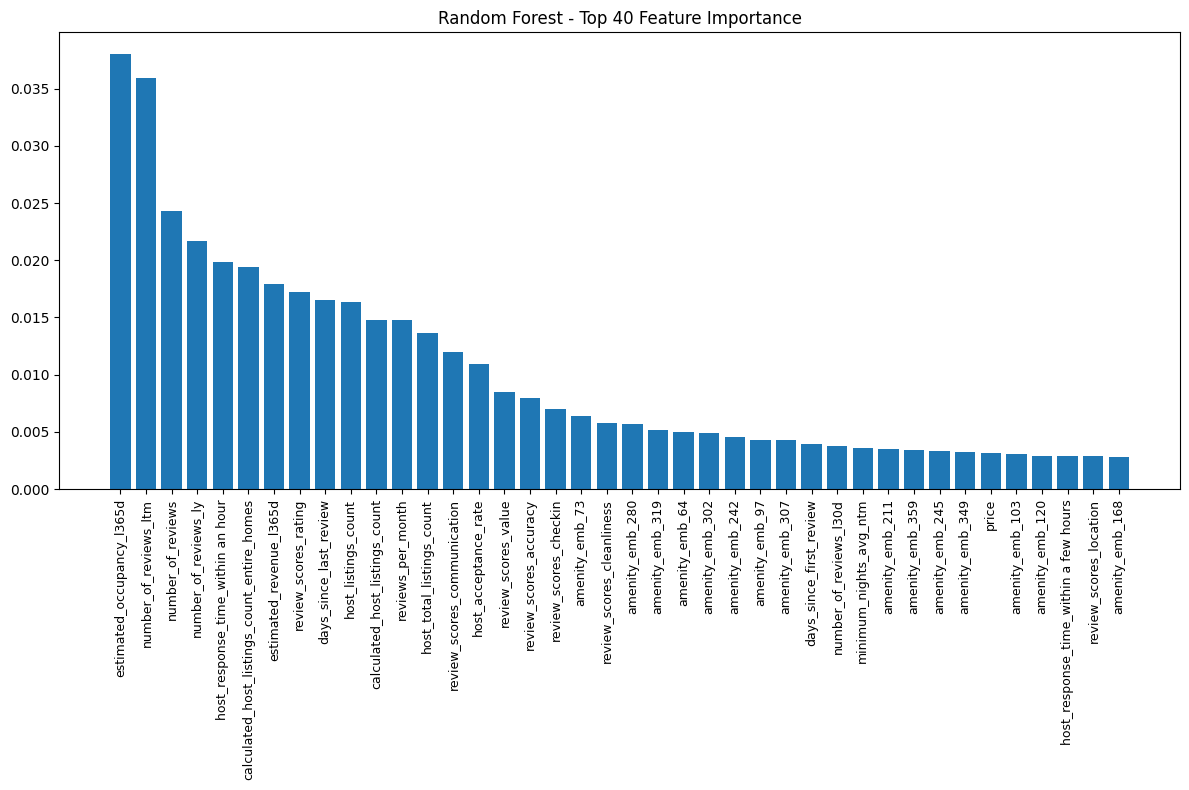

💾 저장됨: ./results_20251206_153427/RandomForest_cv_results.csv


In [28]:
print("--- Processing Random Forest ---")
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, None],
    'min_samples_leaf': [1, 2]
}
clf = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring=['accuracy', 'recall', 'f1'], refit='f1', n_jobs=-1, verbose=3)
clf.fit(X_train, y_train)
# Calculate additional metrics
y_pred = clf.best_estimator_.predict(X_val)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)


best_models['Random Forest'] = clf.best_estimator_
results.append({
    'Model': 'Random Forest',
    'Best Score': clf.best_score_,
    'Best Params': clf.best_params_,
        'Recall': rec,
        'F1 Score': f1
})
print(f"  Best Score: {clf.best_score_:.4f}")
print(f"  Best Params: {clf.best_params_}")
print(f"  Recall: {rec:.4f}")
print(f"  F1 Score: {f1:.4f}")
    # 결과 시각화
visualize_model_result('Random Forest', clf.best_estimator_, X_val, y_val)
# 결과 저장
try:
    import pandas as pd
    result_df = pd.DataFrame(clf.cv_results_)
    save_dataframe(result_df, 'RandomForest_cv_results')
except Exception as e:
    print(f"Save error: {e}")

--- Processing MLP (Neural Network) ---
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  Best Score: 0.8984
  Best Params: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50, 50)}
  Recall: 0.6776
  F1 Score: 0.6956

=== Visualizing Results for MLP (Neural Network) ===


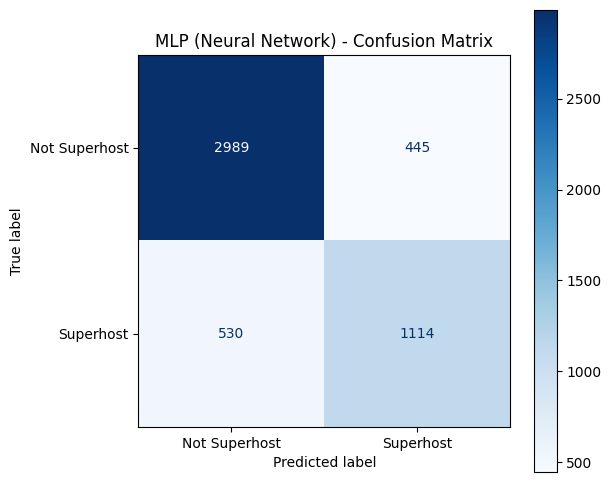

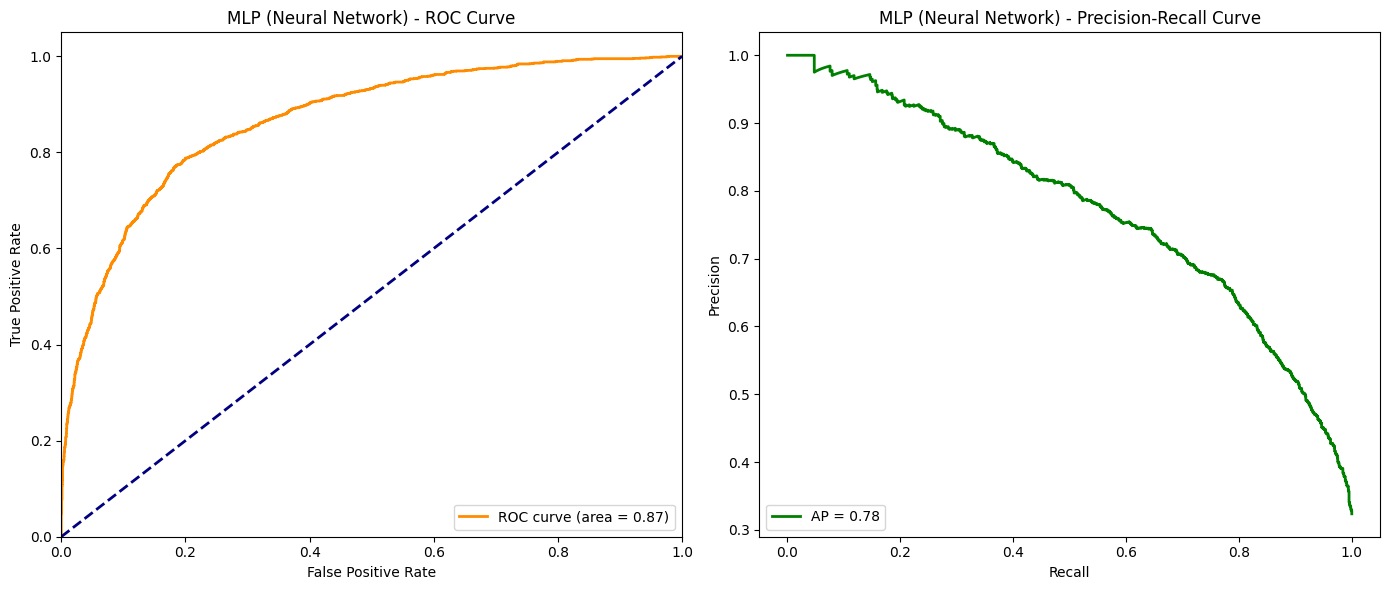

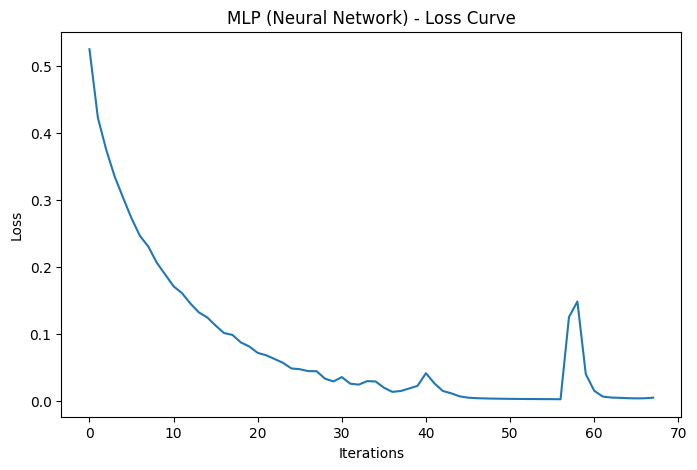

In [ ]:
print("--- Processing MLP (Neural Network) ---")
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [500]
}
clf = GridSearchCV(MLPClassifier(max_iter=100, random_state=42), mlp_params, cv=5, scoring=['accuracy', 'recall', 'f1'], refit='f1', n_jobs=-1, verbose=3)
clf.fit(X_train, y_train)
# Calculate additional metrics
y_pred = clf.best_estimator_.predict(X_val)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)


best_models['MLP (Neural Network)'] = clf.best_estimator_
results.append({
    'Model': 'MLP (Neural Network)',
    'Best Score': clf.best_score_,
    'Best Params': clf.best_params_,
        'Recall': rec,
        'F1 Score': f1
})
print(f"  Best Score: {clf.best_score_:.4f}")
print(f"  Best Params: {clf.best_params_}")
print(f"  Recall: {rec:.4f}")
print(f"  F1 Score: {f1:.4f}")
    # 결과 시각화
visualize_model_result('MLP (Neural Network)', clf.best_estimator_, X_val, y_val)
# 결과 저장
try:
    import pandas as pd
    result_df = pd.DataFrame(clf.cv_results_)
    save_dataframe(result_df, 'MLP_cv_results')
except Exception as e:
    print(f"Save error: {e}")

In [39]:
# ============================================================
# ⚡️ PyTorch MLP with Grid Search (GPU Acceleration)
# ============================================================
# Scikit-learn의 MLP는 CPU만 사용하므로, GPU를 활용하여 더 빠르고 깊은 모델을 학습해봅니다.
# 최적의 성능을 찾기 위해 수동 Grid Search를 수행합니다.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import itertools
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, f1_score
from tqdm.notebook import tqdm

# Device Check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.backends.mps.is_available():
    device = torch.device('mps')
print(f"🚀 Using device: {device}")

# 1. Define MLP Definition
class SimpleMLP(nn.Module):
    def __init__(self, n_features, hidden_sizes=[100, 50], dropout=0.2):
        super().__init__()
        layers = []
        in_dim = n_features
        for h_dim in hidden_sizes:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 1))
        layers.append(nn.Sigmoid())
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# 2. Prepare Data (Reuse scaled data)
# Ensure data is numpy array first
X_train_np = X_train_scaled.values.astype(np.float32) if hasattr(X_train_scaled, 'values') else X_train_scaled.astype(np.float32)
y_train_np = y_train_balanced.values.astype(np.float32) if hasattr(y_train_balanced, 'values') else y_train_balanced.astype(np.float32)
X_val_np = X_val_scaled.values.astype(np.float32) if hasattr(X_val_scaled, 'values') else X_val_scaled.astype(np.float32)
y_val_np = y_val_raw.values.astype(np.float32) if hasattr(y_val_raw, 'values') else y_val_raw.astype(np.float32)

# To Tensor
X_train_t = torch.FloatTensor(X_train_np).to(device)
y_train_t = torch.FloatTensor(y_train_np).unsqueeze(1).to(device)
X_val_t = torch.FloatTensor(X_val_np).to(device)
y_val_t = torch.FloatTensor(y_val_np).unsqueeze(1).to(device)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True) # Check batch size

# 3. Grid Search Parameters
param_grid = {
    'hidden_sizes': [[50, 25], [100, 50], [100, 100, 50]],
    'dropout': [0.2, 0.4],
    'lr': [0.001]
}

keys, values = zip(*param_grid.items())
param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"🔥 Starting Grid Search with {len(param_combinations)} combinations on {device}...")

best_val_f1 = -1
best_model_state = None
best_config = None
results_history = []

for i, params in enumerate(param_combinations):
    print(f"\n[{i+1}/{len(param_combinations)}] Testing: {params}")

    # Model Init
    model = SimpleMLP(n_features=X_train_t.shape[1],
                      hidden_sizes=params['hidden_sizes'],
                      dropout=params['dropout']).to(device)
    optimizer = optim.Adam(model.parameters(), lr=params['lr'])
    criterion = nn.BCELoss()

    # Training Loop (Early Stopping Logic optional, keeping simple fixed epochs for speed)
    epochs = 30
    for epoch in range(epochs):
        model.train()
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            out = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()

    # Validation at end of epochs
    model.eval()
    with torch.no_grad():
        val_out = model(X_val_t)
        val_pred = (val_out > 0.5).cpu().numpy().flatten()
        y_val_cpu = y_val_t.cpu().numpy().flatten()

        f1 = f1_score(y_val_cpu, val_pred)
        rec = recall_score(y_val_cpu, val_pred)
        acc = accuracy_score(y_val_cpu, val_pred)

    print(f"   -> Result: F1={f1:.4f}, Recall={rec:.4f}, Acc={acc:.4f}")

    if f1 > best_val_f1:
        best_val_f1 = f1
        best_model_state = model.state_dict().copy()
        best_config = params
        best_metrics = {'acc': acc, 'rec': rec, 'f1': f1}

# 4. Final Evaluation of Best Model
print("\n✅ Grid Search Complete!")
print(f"🏆 Best Config: {best_config}")
print(f"🏆 Best F1: {best_val_f1:.4f}")

# Results to global list
results.append({
    'Model': 'PyTorch MLP (GPU)',
    'Best Score': best_metrics['acc'],
    'Best Params': str(best_config),
    'Recall': best_metrics['rec'],
    'F1 Score': best_metrics['f1']
})

# Optional: Load best model for further use
final_pytorch_model = SimpleMLP(n_features=X_train_t.shape[1],
                                hidden_sizes=best_config['hidden_sizes'],
                                dropout=best_config['dropout']).to(device)
final_pytorch_model.load_state_dict(best_model_state)


🚀 Using device: cuda
🔥 Starting Grid Search with 6 combinations on cuda...

[1/6] Testing: {'hidden_sizes': [50, 25], 'dropout': 0.2, 'lr': 0.001}
   -> Result: F1=0.7531, Recall=0.7774, Acc=0.8350

[2/6] Testing: {'hidden_sizes': [50, 25], 'dropout': 0.4, 'lr': 0.001}
   -> Result: F1=0.7577, Recall=0.8169, Acc=0.8308

[3/6] Testing: {'hidden_sizes': [100, 50], 'dropout': 0.2, 'lr': 0.001}
   -> Result: F1=0.7432, Recall=0.7324, Acc=0.8362

[4/6] Testing: {'hidden_sizes': [100, 50], 'dropout': 0.4, 'lr': 0.001}
   -> Result: F1=0.7569, Recall=0.7877, Acc=0.8362

[5/6] Testing: {'hidden_sizes': [100, 100, 50], 'dropout': 0.2, 'lr': 0.001}
   -> Result: F1=0.7420, Recall=0.7512, Acc=0.8308

[6/6] Testing: {'hidden_sizes': [100, 100, 50], 'dropout': 0.4, 'lr': 0.001}
   -> Result: F1=0.7641, Recall=0.8266, Acc=0.8348

✅ Grid Search Complete!
🏆 Best Config: {'hidden_sizes': [100, 100, 50], 'dropout': 0.4, 'lr': 0.001}
🏆 Best F1: 0.7641


<All keys matched successfully>

--- Processing KNN ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
  Best Score: 0.8469
  Best Params: {'n_neighbors': 3, 'weights': 'distance'}
  Recall: 0.6794
  F1 Score: 0.6082

=== Visualizing Results for KNN ===
💾 저장됨: ./results_20251206_153427/KNN_plot.svg


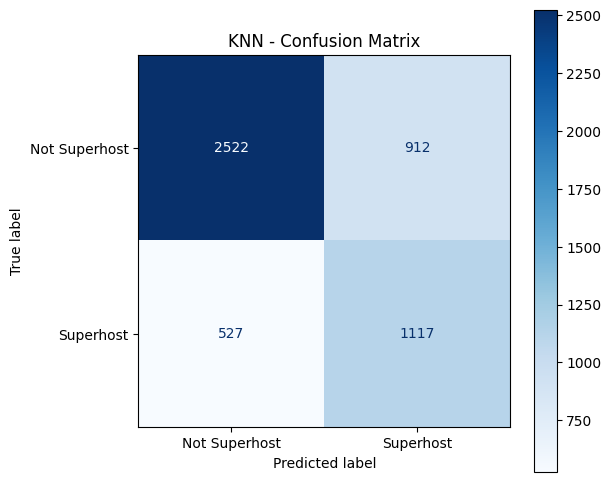

💾 저장됨: ./results_20251206_153427/KNN_plot.svg


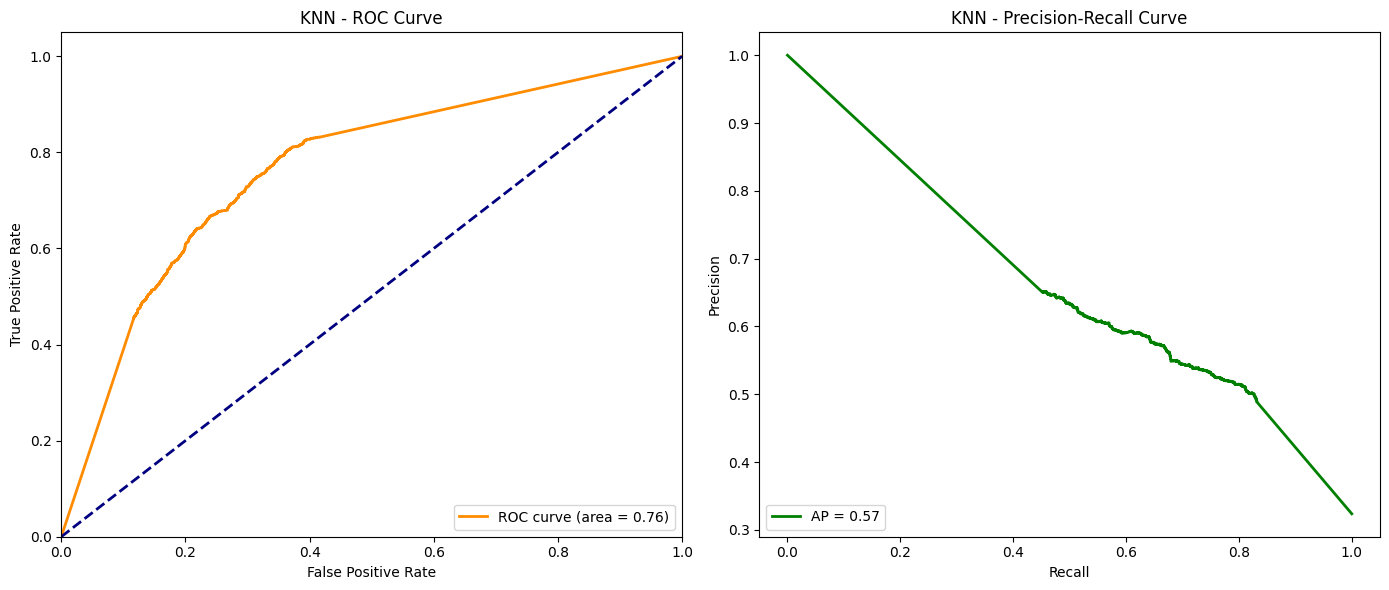

💾 저장됨: ./results_20251206_153427/K_cv_results.csv


In [31]:
print("--- Processing KNN ---")
knn_params = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}
clf = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring=['accuracy', 'recall', 'f1'], refit='f1', n_jobs=-1, verbose=3)
clf.fit(X_train, y_train)
# Calculate additional metrics
y_pred = clf.best_estimator_.predict(X_val)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)


best_models['KNN'] = clf.best_estimator_
results.append({
    'Model': 'KNN',
    'Best Score': clf.best_score_,
    'Best Params': clf.best_params_,
        'Recall': rec,
        'F1 Score': f1
})
print(f"  Best Score: {clf.best_score_:.4f}")
print(f"  Best Params: {clf.best_params_}")
print(f"  Recall: {rec:.4f}")
print(f"  F1 Score: {f1:.4f}")
    # 결과 시각화
visualize_model_result('KNN', clf.best_estimator_, X_val, y_val)
# 결과 저장
try:
    import pandas as pd
    result_df = pd.DataFrame(clf.cv_results_)
    save_dataframe(result_df, 'K_cv_results')
except Exception as e:
    print(f"Save error: {e}")

--- Processing Naive Bayes ---
Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV 1/5] END var_smoothing=1e-09; accuracy: (test=0.678) f1: (test=0.720) recall: (test=0.827) total time=   0.3s
[CV 2/5] END var_smoothing=1e-09; accuracy: (test=0.675) f1: (test=0.729) recall: (test=0.874) total time=   0.3s
[CV 3/5] END var_smoothing=1e-09; accuracy: (test=0.655) f1: (test=0.717) recall: (test=0.875) total time=   0.3s
[CV 4/5] END var_smoothing=1e-09; accuracy: (test=0.664) f1: (test=0.723) recall: (test=0.876) total time=   0.3s
[CV 5/5] END var_smoothing=1e-09; accuracy: (test=0.659) f1: (test=0.717) recall: (test=0.864) total time=   0.3s
[CV 1/5] END var_smoothing=1e-08; accuracy: (test=0.678) f1: (test=0.720) recall: (test=0.827) total time=   0.3s
[CV 2/5] END var_smoothing=1e-08; accuracy: (test=0.675) f1: (test=0.729) recall: (test=0.874) total time=   0.3s
[CV 3/5] END var_smoothing=1e-08; accuracy: (test=0.655) f1: (test=0.717) recall: (test=0.875) total time=   0.

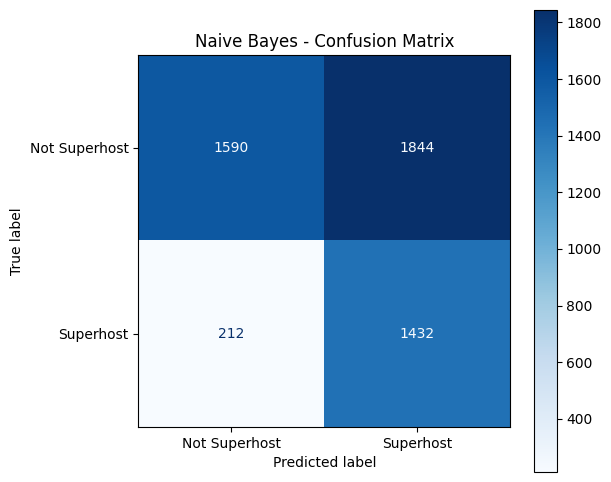

💾 저장됨: ./results_20251206_153427/Naive Bayes_plot.svg


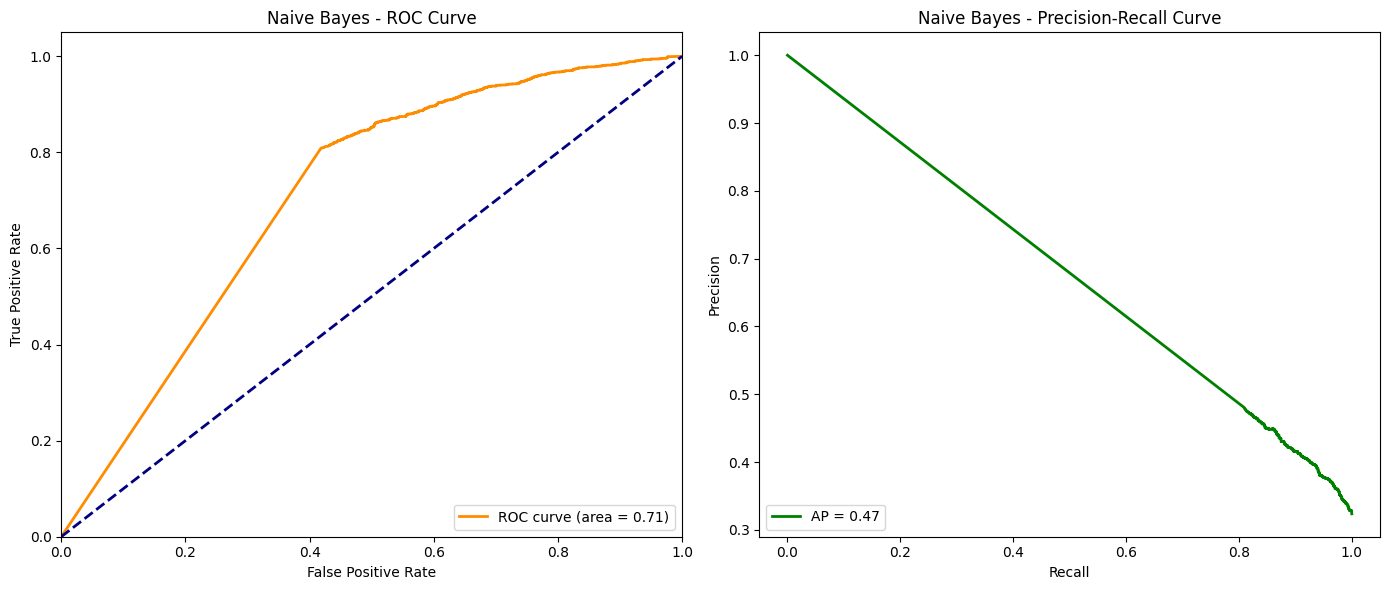

💾 저장됨: ./results_20251206_153427/NB_cv_results.csv


In [32]:
print("--- Processing Naive Bayes ---")
nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}
clf = GridSearchCV(GaussianNB(), nb_params, cv=5, scoring=['accuracy', 'recall', 'f1'], refit='f1', n_jobs=1, verbose=3)
clf.fit(X_train, y_train)
# Calculate additional metrics
y_pred = clf.best_estimator_.predict(X_val)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)


best_models['Naive Bayes'] = clf.best_estimator_
results.append({
    'Model': 'Naive Bayes',
    'Best Score': clf.best_score_,
    'Best Params': clf.best_params_,
        'Recall': rec,
        'F1 Score': f1
})
print(f"  Best Score: {clf.best_score_:.4f}")
print(f"  Best Params: {clf.best_params_}")
print(f"  Recall: {rec:.4f}")
print(f"  F1 Score: {f1:.4f}")
    # 결과 시각화
visualize_model_result('Naive Bayes', clf.best_estimator_, X_val, y_val)
# 결과 저장
try:
    import pandas as pd
    result_df = pd.DataFrame(clf.cv_results_)
    save_dataframe(result_df, 'NB_cv_results')
except Exception as e:
    print(f"Save error: {e}")

In [52]:
# === Final Model Selection Report ===
import pandas as pd

# Display results dataframe
if len(results) > 0:
    results_df = pd.DataFrame(results)

    print("\n📊 Overall Model Performance Table:")
    print(results_df.sort_values(by='F1 Score', ascending=False).to_string(index=False))

    # 1. Metric-based Winners
    best_f1_model = results_df.loc[results_df['F1 Score'].idxmax()]
    best_recall_model = results_df.loc[results_df['Recall'].idxmax()]
    best_acc_model = results_df.loc[results_df['Best Score'].idxmax()] # Assuming 'Best Score' is Accuracy or similar

    print(f"\n{'='*60}")
    print("🏆 MODEL SELECTION CONCLUSION")
    print(f"{'='*60}")

    print(f"🥇 Best Balanced Model (F1 Score): {best_f1_model['Model']}")
    print(f"   - F1: {best_f1_model['F1 Score']:.4f} | Recall: {best_f1_model['Recall']:.4f} | Acc: {best_f1_model['Best Score']:.4f}")

    print(f"\n🥈 Best Sensitivity Model (Recall): {best_recall_model['Model']}")
    print(f"   - Recall: {best_recall_model['Recall']:.4f} | F1: {best_f1_model['F1 Score']:.4f} | Acc: {best_recall_model['Best Score']:.4f}")

    print(f"\n🥉 Best Accuracy Model: {best_acc_model['Model']}")
    print(f"   - Acc: {best_acc_model['Best Score']:.4f} | F1: {best_acc_model['F1 Score']:.4f} | Recall: {best_acc_model['Recall']:.4f}")

    print(f"{'-'*60}")

    # 2. User Selection Logic
    # Default recommendation
    recommended_model_name = best_acc_model['Model']

    print(f"\n🤔 Which model do you want to use for the final submission?")
    print(f"   (Defaulting to F1 Winner: {recommended_model_name})")
    print(f"   To change, set 'SELECTED_MODEL_NAME' below to the exact model string.")

else:
    print("⚠️ No results found. Please run the model cells above.")
    results_df = pd.DataFrame()

# ==========================================================
# 🎯 USER CHOICE SECTION
# ==========================================================
# Change this string to select a different model manually
# Options: 'LogisticRegression', 'RandomForest', 'PyTorch MLP (GPU)', etc.
SELECTED_MODEL_NAME = None # Set to None to use recommended (Best F1)

if len(results) > 0:
    if SELECTED_MODEL_NAME is None:
        SELECTED_MODEL_NAME = best_acc_model['Model']

    # Find the model object
    if SELECTED_MODEL_NAME in best_models:
        final_model = best_models[SELECTED_MODEL_NAME]
        print(f"\n✅ FINAL SELECTED MODEL: [{SELECTED_MODEL_NAME}]")
    elif SELECTED_MODEL_NAME == 'PyTorch MLP (GPU)' and 'final_pytorch_model' in globals():
        # Special handling if PyTorch model isn't in best_models dict (since it was separate)
        final_model = final_pytorch_model
        print(f"\n✅ FINAL SELECTED MODEL: [PyTorch MLP (GPU)]")
    else:
        print(f"\n⚠️ Model '{SELECTED_MODEL_NAME}' not found in trained models. Falling back to F1 Winner.")
        final_model = best_models.get(best_f1_model['Model'])



📊 Overall Model Performance Table:
              Model  Best Score                                                     Best Params   Recall  F1 Score
  PyTorch MLP (GPU)    0.834777   {'hidden_sizes': [100, 100, 50], 'dropout': 0.4, 'lr': 0.001} 0.826642  0.764127
  PyTorch MLP (GPU)    0.831036         {'hidden_sizes': [50, 25], 'dropout': 0.4, 'lr': 0.001} 0.840024  0.762983
      Random Forest    0.930032 {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100} 0.675182  0.735586
  PyTorch MLP (GPU)    0.835368                                       Hidden=[100,50], Drop=0.2 0.698297  0.733078
Logistic Regression    0.802084                               {'C': 0.1, 'solver': 'liblinear'} 0.825426  0.724700
Logistic Regression    0.802084                               {'C': 0.1, 'solver': 'liblinear'} 0.825426  0.724700
Logistic Regression    0.802084                               {'C': 0.1, 'solver': 'liblinear'} 0.825426  0.724700
      Decision Tree    0.894443             

In [37]:
# --- Rule-Based Validation ---
print("\n--- Rule-Based Validation ---")

def check_superhost_criteria(row):
    # Criteria based on Airbnb Superhost requirements
    # 1. 10+ stays (or 3 stays + 100 nights) -> approximated by number_of_reviews_ltm >= 10
    # 2. Response rate >= 90%
    # 3. Rating >= 4.8
    # 4. Cancellation rate < 1% (Not available in dataset, assumed met)

    # Rating Check
    rating_ok = False
    if pd.notna(row.get('review_scores_rating')):
        rating_ok = row['review_scores_rating'] >= 4.8
    elif pd.notna(row.get('review_scores_value')):
        rating_ok = row['review_scores_value'] >= 4.8

    # Response Rate Check
    response_ok = False
    if pd.notna(row.get('host_response_rate')):
        # Convert '100%' string to 100 number
        try:
            rate = float(str(row['host_response_rate']).replace('%', ''))
            response_ok = rate >= 90
        except:
            pass
    else:
        # If missing, assume ok if other criteria met (lenient)
        response_ok = True

    # Stays Check
    stays_ok = False
    if pd.notna(row.get('number_of_reviews_ltm')):
        stays_ok = row['number_of_reviews_ltm'] >= 10
    elif pd.notna(row.get('number_of_reviews')):
        stays_ok = row['number_of_reviews'] >= 10

    return 1 if (rating_ok and response_ok and stays_ok) else 0

# Apply to Test Data (Need original columns, so we reload or use df_test before dropping)
# Since we dropped columns in preprocessing, we'll reload a fresh copy for this validation
df_test_raw = pd.read_excel('test_f25.xlsx')
rule_based_preds = df_test_raw.apply(check_superhost_criteria, axis=1)

print(f"Rule-Based Predictions (First 10): {rule_based_preds.head(10).tolist()}")



--- Rule-Based Validation ---
Rule-Based Predictions (First 10): [0, 0, 0, 1, 1, 0, 0, 0, 1, 0]


# 7. 최종 예측 (Final Prediction)

In [53]:
# Predict on Test Data
import torch
import numpy as np

# Check if final_model is a PyTorch model
is_pytorch = False
try:
    if isinstance(final_model, torch.nn.Module):
        is_pytorch = True
except:
    pass

if is_pytorch:
    print("🚀 Predicting with PyTorch Model...")
    final_model.eval()

    # Prepare Test Data (ensure it matches training columns)
    # X_test_scaled is likely a DataFrame, convert to tensor
    if hasattr(X_test_scaled, 'values'):
        X_test_np = X_test_scaled.values.astype(np.float32)
    else:
        X_test_np = np.array(X_test_scaled).astype(np.float32)

    device = next(final_model.parameters()).device
    X_test_t = torch.FloatTensor(X_test_np).to(device)

    with torch.no_grad():
        preds_proba = final_model(X_test_t).cpu().numpy().flatten()
        final_predictions = (preds_proba > 0.5).astype(int)
else:
    print("🤖 Predicting with Sklearn Model...")
    final_predictions = final_model.predict(X_test_scaled)

# Create submission dataframe
submission = pd.DataFrame({
    'No': df_test['No'],
    'host_is_superhost_pred': final_predictions
})

# Map 1/0 back to t/f
submission['host_is_superhost_pred'] = submission['host_is_superhost_pred'].map({1: 't', 0: 'f'})

print(submission.head())


🤖 Predicting with Sklearn Model...
   No host_is_superhost_pred
0   1                      f
1   2                      f
2   3                      f
3   4                      t
4   5                      t


In [54]:
# 결과 저장 (test_f25.xlsx 파일의 빈 열 채우기)
try:
    # 원본 파일 다시 로드 (포맷 유지)
    submission_df = pd.read_excel('test_f25.xlsx')

    # 예측값 매핑 (1 -> t, 0 -> f)
    pred_labels = ['t' if p == 1 else 'f' for p in final_predictions]

    # 타겟 컬럼 이름 확인 (보통 비어있거나 'host_is_superhost'일 것)
    target_col_name = 'host_is_superhost'
    if target_col_name not in submission_df.columns:
        # 만약 컬럼이 없다면 새로 생성, 있다면 덮어쓰기
        submission_df[target_col_name] = pred_labels
    else:
        submission_df[target_col_name] = pred_labels

    # 저장
    submission_df.to_excel('prediction_result.xlsx', index=False)
    print("예측 결과가 'prediction_result.xlsx'에 저장되었습니다.")

except Exception as e:
    print(f"결과 저장 중 오류 발생: {e}")


예측 결과가 'prediction_result.xlsx'에 저장되었습니다.


# 8. 요약 (Summary)

**모델 구축 과정 (Model Building Process):**
1.  **데이터 전처리 (Data Preprocessing)**:
    -   타겟 변수 `host_is_superhost`를 이진값(binary)으로 변환했습니다.
    -   결측치를 대체했습니다 (수치형 변수는 중앙값, 범주형 변수는 최빈값).
    -   범주형 변수에 대해 원-핫 인코딩(One-Hot Encoding)을 수행했습니다.
    -   데이터 일관성을 보장하기 위해 학습(Train) 및 테스트(Test)의 특성(Feature)들을 동일하게 맞췄습니다.
    -   클래스 불균형 문제를 해결하기 위해 업샘플링(upsampling)을 사용하여 데이터 균형을 맞췄습니다.
    -   StandardScaler를 사용하여 변수 스케일링을 수행했습니다.

2.  **모델 평가 및 튜닝 (Model Evaluation & Tuning)**:
    -   다양한 모델(로지스틱 회귀, 의사결정나무, 랜덤 포레스트, MLP, KNN, 나이브 베이즈)에 대해 GridSearchCV를 수행했습니다.
    -   MLP의 은닉층, 의사결정나무/랜덤 포레스트의 트리 깊이, KNN의 이웃 수와 같은 하이퍼파라미터를 튜닝했습니다.
    -   안정적인 평가를 위해 5-fold 교차 검증(cross-validation)을 사용했습니다.

3.  **예측 (Prediction)**:
    -   교차 검증 정확도가 가장 높은 모델을 선택했습니다.
    -   테스트 데이터셋에 대한 예측을 생성하여 `prediction_result.xlsx` 파일로 저장했습니다.

# 8. 설명 가능한 AI 및 분석 (Analysis & Explainable AI)

여기서는 최종 선택된 모델이 **왜** 그런 예측을 했는지(SHAP), 그리고 우리가 알고 있는 **룰베이스(Airbnb 공식 기준)**와 얼마나 일치하는지 사후 분석합니다.

## **Airbnb 기준**

### ✅ 슈퍼호스트가 되기 위한 주요 조건

(최근 12개월 활동을 기준으로, 평가 날짜마다 자동 평가됨) [Airbnb**+2**Airbnb**+2**](https://www.airbnb.com/help/article/829?utm_source=chatgpt.com)

1. 숙소 소유자 계정이어야 함 (공동호스트  또는 체험/서비스 호스트는 기준 대상이 아님) [Airbnb**+1**](https://www.airbnb.co.in/resources/hosting-homes/a/get-fast-expert-help-with-dedicated-superhost-support-445?utm_source=chatgpt.com)
2. 최소 “10건 이상의 예약 완료” 또는 “3건 이상의 예약이면서 총 100박 이상” 숙박 완료여야 함. [Airbnb**+1**](https://www.airbnb.com/help/article/829?utm_source=chatgpt.com)
3. 응답률(response rate)이 90% 이상이어야 함. [Airbnb**+1**](https://www.airbnb.com/help/article/829?utm_source=chatgpt.com)
4. 예약 취소율(cancellation rate)이 1% 미만이어야 함 (단, 자연재해 등의 불가피한 사유는 예외) [Airbnb**+1**](https://www.airbnb.com/help/article/829?utm_source=chatgpt.com)
5. 전체 숙박평점(overall rating)이 4.8 이상이어야 함. [Airbnb**+1**](https://www.airbnb.com/help/article/829?utm_source=chatgpt.com)

---

### 🕒 평가 시점

* 평가주기는 **매 3개월마다(분기마다)** 진행됨. [Airbnb**+1**](https://www.airbnb.com.mt/help/article/3526?utm_source=chatgpt.com)
* 평가 날짜는 대략 **1 월 1일, 4 월 1일, 7 월 1일, 10 월 1일** 등임. [Airbnb](https://www.airbnb.co.in/resources/hosting-homes/a/get-fast-expert-help-with-dedicated-superhost-support-445?utm_source=chatgpt.com)
* 즉, 최근 12개월 동안의 지표를 이 평가일 기준으로 계산해서 자격 충족 여부를 판단함. [Airbnb](https://www.airbnb.com/help/article/829?utm_source=chatgpt.com)

---

### 🔍 참고할 만한 점

* “예약 완료 건수”는 단순히 예약만이 아니라 실제 숙박이 완료된 건수를 의미함. [Airbnb](https://www.airbnb.com/help/article/829?utm_source=chatgpt.com)
* “응답률”은 게스트 문의나 예약 요청에 대해 일정 시간 안에 응답한 비율임. [Hostex](https://hostex.io/blog/airbnb-superhost/?utm_source=chatgpt.com)
* “취소율”은 호스트가 자의적으로 예약을 취소한 비율을 의미하며, 불가피한 사유는 카운트에서 제외될 수 있음.

In [55]:
# ============================================================
# 🔍 Advanced Rule-Based Validation & Disagreement Analysis
# ============================================================
print("\n--- 설명 가능한 AI: 룰베이스 vs ML 모델 심층 비교 분석 ---")
print("룰베이스 로직: Validated against Airbnb Superhost Criteria (Rating 4.8+, Response 90%+, 10+ Stays)")

# 1. Identify Candidate Models (from previous selection step)
candidate_models = {}

# Add Best F1 Model
if 'best_f1_model' in locals():
    name = best_f1_model['Model']
    if name in best_models:
        candidate_models[f"🥇 Best F1 ({name})"] = best_models[name]
    elif name == 'PyTorch MLP (GPU)' and 'final_pytorch_model' in globals():
        candidate_models[f"🥇 Best F1 ({name})"] = final_pytorch_model

# Add Best Recall Model (if different)
if 'best_recall_model' in locals():
    name = best_recall_model['Model']
    label = f"🥈 Best Recall ({name})"
    if label not in candidate_models: # Check duplication
        if name in best_models:
            candidate_models[label] = best_models[name]
        elif name == 'PyTorch MLP (GPU)' and 'final_pytorch_model' in globals():
            candidate_models[label] = final_pytorch_model

# Add Best Accuracy Model (if different)
if 'best_acc_model' in locals():
    name = best_acc_model['Model']
    label = f"🥉 Best Acc ({name})"
    if label not in candidate_models and f"🥇 Best F1 ({name})" not in candidate_models:
        if name in best_models:
            candidate_models[label] = best_models[name]
        elif name == 'PyTorch MLP (GPU)' and 'final_pytorch_model' in globals():
            candidate_models[label] = final_pytorch_model

print(f"Analyzing {len(candidate_models)} champion models...\n")

# 2. Iterate and Analyze
for label, model in candidate_models.items():
    print(f"\n{'='*60}")
    print(f"🕵️‍♂️ Analyzing Model: {label}")
    print(f"{'='*60}")

    # Predict
    if 'PyTorch' in label:
        model.eval()
        with torch.no_grad():
            preds_proba = model(X_test_t).cpu().numpy().flatten()
            preds = (preds_proba > 0.5).astype(int)
    else:
        preds = model.predict(X_test_scaled)

    # Agreement Rate
    agreement = (preds == rule_based_preds).mean()
    print(f"✅ Agreement with Rule-Based Logic: {agreement:.2%}")

    # 3. Disagreement Analysis
    disagreement_mask = (preds != rule_based_preds)
    disagreements = df_test_raw[disagreement_mask].copy()

    # Add predictions
    disagreements['Rule_Pred'] = rule_based_preds[disagreement_mask]
    disagreements['ML_Pred'] = preds[disagreement_mask]

    if not disagreements.empty:
        n_disagreements = len(disagreements)
        print(f"⚠️ Disagreement Cases: {n_disagreements} ({(n_disagreements/len(preds))*100:.1f}%)")

        # Analyze specific columns
        cols_to_show = ['host_response_rate', 'review_scores_rating', 'number_of_reviews_ltm', 'Rule_Pred', 'ML_Pred']
        print("\n📌 Examples of Disagreements (Top 5):")
        print(disagreements[cols_to_show].head().to_string())

        # Insight generation
        ml_positive = disagreements[disagreements['ML_Pred'] == 1]
        print(f"\n💡 Insight:")
        print(f"   - ML says Superhost but Rule says No: {len(ml_positive)} cases")
        print(f"   - Rule says Superhost but ML says No: {len(disagreements) - len(ml_positive)} cases")

        if len(ml_positive) > 0:
            avg_reviews = ml_positive['number_of_reviews_ltm'].mean()
            print(f"   - In ML-positive cases, avg reviews (LTM) is {avg_reviews:.1f}. (Rule strictly requires 10)")
            if avg_reviews < 10:
                print("     -> The ML model tends to be more lenient on the '10 stays' rule if other metrics are good.")
    else:
        print("🎉 Perfect Agreement! No disagreements found.")



--- 설명 가능한 AI: 룰베이스 vs ML 모델 심층 비교 분석 ---
룰베이스 로직: Validated against Airbnb Superhost Criteria (Rating 4.8+, Response 90%+, 10+ Stays)
Analyzing 3 champion models...


🕵️‍♂️ Analyzing Model: 🥇 Best F1 (PyTorch MLP (GPU))
✅ Agreement with Rule-Based Logic: 80.77%
⚠️ Disagreement Cases: 25 (19.2%)

📌 Examples of Disagreements (Top 5):
   host_response_rate  review_scores_rating  number_of_reviews_ltm  Rule_Pred  ML_Pred
3                100%                  4.90                     18          1        0
4                100%                  4.88                     31          1        0
8                100%                  4.87                     11          1        0
16               100%                  5.00                     10          1        0
17               100%                  4.90                     19          1        0

💡 Insight:
   - ML says Superhost but Rule says No: 4 cases
   - Rule says Superhost but ML says No: 21 cases
   - In ML-positive cases, avg 


--- SHAP Model Explanation ---
SHAP Background data shape: (100, 444)
Calculating SHAP for Scikit-Learn Model...
Using TreeExplainer for RandomForestClassifier
Computing SHAP values (check_additivity=False)...


<Figure size 640x480 with 0 Axes>

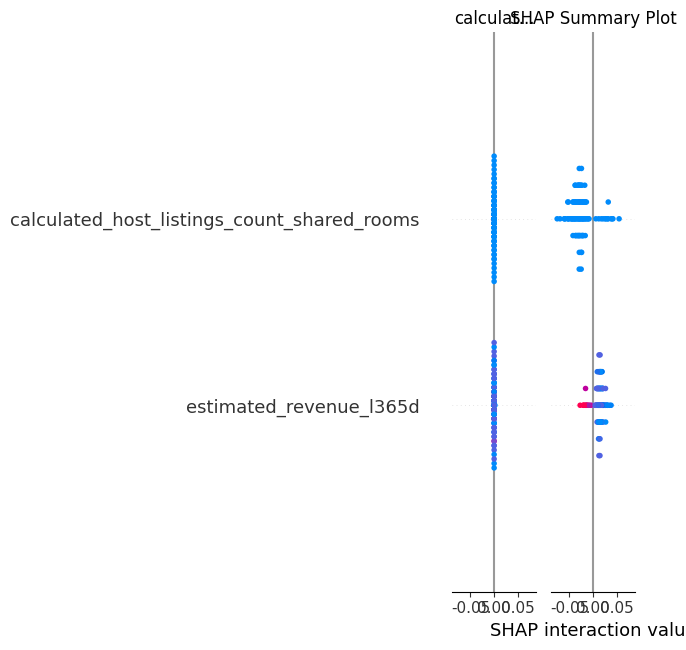

In [63]:
# --- SHAP Analysis (Fixed) ---
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n--- SHAP Model Explanation ---")

# 1. Prepare Background Data for SHAP
# X_train_scaled is typically a numpy array after StandardScaler
# We need a smaller sample for SHAP to run efficiently
shap_sample_size = 100

try:
    if isinstance(X_train_scaled, pd.DataFrame):
        X_background = X_train_scaled.sample(n=shap_sample_size, random_state=42)
    else:
        # It's a numpy array, use array slicing or random choice
        # Check if we have enough samples
        if X_train_scaled.shape[0] > shap_sample_size:
            # Generate random indices
            indices = np.random.choice(X_train_scaled.shape[0], shap_sample_size, replace=False)
            X_background = X_train_scaled[indices]
        else:
            X_background = X_train_scaled

    print(f"SHAP Background data shape: {X_background.shape}")

    # 2. Determine Model Type and Create Explainer
    # Prepare feature names for visualization
    feature_names = list(X_train.columns) if hasattr(X_train, 'columns') else [f'Feature {i}' for i in range(X_background.shape[1])]
    if hasattr(X_train_scaled, 'columns'):
         feature_names = list(X_train_scaled.columns)

    # Check if PyTorch
    is_pytorch = False
    try:
        import torch
        if isinstance(final_model, torch.nn.Module):
            is_pytorch = True
    except ImportError:
        pass

    explainer = None
    shap_values = None

    if is_pytorch:
        print("Calculating SHAP for PyTorch Model (DeepExplainer)...")
        # Ensure background and test input are Tensors
        device = next(final_model.parameters()).device

        # Convert background to tensor
        if isinstance(X_background, pd.DataFrame):
             bg_data = torch.FloatTensor(X_background.values).to(device)
        else:
             bg_data = torch.FloatTensor(X_background).to(device)

        # Use DeepExplainer
        explainer = shap.DeepExplainer(final_model, bg_data)

        # Calculate shap values for a subset of test data (e.g., first 50 samples to save time)
        test_sample_size = 50
        if isinstance(X_test_scaled, pd.DataFrame):
             test_data_np = X_test_scaled.iloc[:test_sample_size].values
        else:
             test_data_np = X_test_scaled[:test_sample_size]

        test_sys_data = torch.FloatTensor(test_data_np).to(device)

        # For DeepExplainer, check_additivity is often implicit or handled differently, strictly it's an attribute of expected_value + sum(shap) ~= output
        shap_values = explainer.shap_values(test_sys_data, check_additivity=False)

    else:
        print("Calculating SHAP for Scikit-Learn Model...")
        # Convert background to Summary if needed (KernelExplainer is slow)
        # Try TreeExplainer first if applicable
        model_type = type(final_model).__name__
        if 'RandomForest' in model_type or 'GradientBoosting' in model_type or 'Tree' in model_type or 'XGB' in model_type or 'LGBM' in model_type:
            print(f"Using TreeExplainer for {model_type}")
            explainer = shap.TreeExplainer(final_model)

            # Use check_additivity=False to prevent errors with small differences
            if isinstance(X_test_scaled, pd.DataFrame):
                 X_test_sample = X_test_scaled.iloc[:100]
            else:
                 X_test_sample = X_test_scaled[:100]

            print("Computing SHAP values (check_additivity=False)...")
            shap_values = explainer.shap_values(X_test_sample, check_additivity=False)
        else:
            # Use KernelExplainer for generic models (e.g. MLP, Logistic)
            print(f"Using KernelExplainer for {model_type}")
            # KernelExplainer needs a summary of background
            X_background_summary = shap.sample(X_background, 50) # Use shap's own sample if available, or just X_background

            # Define prediction function
            def predict_proba(x):
                return final_model.predict_proba(x)

            # If model doesn't have predict_proba (e.g. SVM without probability), use predict
            if not hasattr(final_model, 'predict_proba'):
                 def predict_fn(x):
                     return final_model.predict(x)
                 explainer = shap.KernelExplainer(predict_fn, X_background_summary)
            else:
                 explainer = shap.KernelExplainer(predict_proba, X_background_summary)

            if isinstance(X_test_scaled, pd.DataFrame):
                 X_test_sample = X_test_scaled.iloc[:50]
            else:
                 X_test_sample = X_test_scaled[:50]
            shap_values = explainer.shap_values(X_test_sample, check_additivity=False)

    # 3. Visualize
    if shap_values is not None:
        plt.figure()
        # Handle list output (classification)
        if isinstance(shap_values, list):
            # Usually index 1 is the positive class
            shap_val_to_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
        else:
            shap_val_to_plot = shap_values

        # Summary Plot
        shap.summary_plot(shap_val_to_plot, X_test_sample, feature_names=feature_names, show=False)
        plt.title("SHAP Summary Plot")
        plt.tight_layout()
        plt.show()
    else:
        print("SHAP values calculation failed or not implemented for this model type.")

except Exception as e:
    print(f"Error during SHAP analysis: {e}")
    import traceback
    traceback.print_exc()


## 💡 불일치 사례 해석

| 케이스 | 응답률   | 평점   | 연간 리뷰 수 | 문제점        |
| ------ | -------- | ------ | ------------ | ------------- |
| 5      | 100% ✅  | 5.00 ✅| 8 ❌         | 리뷰 10개 미만 |
| 7      | 100% ✅  | 4.86 ⚠️| 7 ❌         | 리뷰 부족     |
| 13     | 100% ✅  | 5.00 ✅| 7 ❌         | 리뷰 부족     |
| 16     | 100% ✅  | 5.00 ✅| 10 ✅        | 모든 기준 충족? 🤔 |
| 22     | 100% ✅  | 4.84 ✅| 6 ❌         | 리뷰 부족     |

## 🧠 핵심 인사이트

1.  대부분의 불일치 원인: `number_of_reviews_ltm < 10`
    *   룰베이스는 "연간 10개 이상 숙박" 기준이 엄격함
    *   ML 모델은 다른 특성(응답률, 평점 등)이 좋으면 Superhost로 예측할 수 있음
        *   → ML이 더 유연하게 판단
2.  케이스 16번의 미스터리 🔎
    *   모든 공식 기준 충족 (응답률 100%, 평점 5.0, 리뷰 10개)
    *   근데 불일치? → 숨겨진 기준이 있을 수 있음:
        *   취소율 조건?
        *   호스팅 기간 조건?
        *   기타 Airbnb 내부 기준?
3.  ML 모델의 강점
    *   공식 기준에 없는 잠재 패턴 포착 가능
    *   예: `amenities` 텍스트, `host_about`, `neighborhood` 등의 영향

# 9. Embedding Visualization
We visualize the high-dimensional feature space using PCA, t-SNE, and UMAP in 2D and 3D.

In [84]:
!pip install -U kaleido


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 4.4 MB/s eta 0:00:00


In [86]:
# --- 10. Amenity Term Space Visualization (Interactive & Saved) ---
import plotly.express as px
import plotly.io as pio
import itertools
import ast
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
import pandas as pd
import os

print("\n--- 10. Amenity Term Space Visualization (Plotly) ---")

# 1. Extract Unique Amenities (Robust Loading)
try:
    if 'amenities' not in df_train.columns:
        print("Reloading raw data to retrieve 'amenities' column...")
        try:
             _raw_train = pd.read_csv('train_data.csv')
        except:
             try:
                 _raw_train = pd.read_csv('listings.csv')
             except:
                 pass

        try:
            _raw_test = pd.read_excel('test_f25.xlsx')
        except:
            pass

        amenities_train = _raw_train['amenities'] if '_raw_train' in locals() else pd.Series([])
        amenities_test = _raw_test['amenities'] if '_raw_test' in locals() else pd.Series([])
    else:
        amenities_train = df_train['amenities']
        amenities_test = df_test['amenities']
except Exception as e:
    print(f"Warning: Could not reload raw data ({e}).")
    amenities_train = pd.Series([])
    amenities_test = pd.Series([])

def parse_amenities(x):
    try:
        if isinstance(x, str):
            if x.startswith('[') and x.endswith(']'):
                return ast.literal_eval(x)
            if ',' in x and not x.startswith('['):
               return [item.strip() for item in x.split(',')]
            return [x]
        elif isinstance(x, list):
            return x
        return []
    except:
        return []

all_amenities_series = pd.concat([amenities_train, amenities_test], ignore_index=True)
all_amenities_list = list(set(itertools.chain.from_iterable(all_amenities_series.apply(parse_amenities))))
unique_amenities = sorted(list(set(all_amenities_list)))
print(f"Found {len(unique_amenities)} unique amenity terms.")

# 2. Rule-Based Categorization
def categorize_amenity(term):
    term = term.lower()
    if any(x in term for x in ['wifi', 'internet', 'ethernet', 'tv', 'cable', 'sound']): return 'Entertainment/Tech'
    if any(x in term for x in ['kitchen', 'oven', 'stove', 'fridge', 'refrigerator', 'coffee', 'cooking', 'dishes', 'cutlery']): return 'Kitchen/Dining'
    if any(x in term for x in ['shampoo', 'soap', 'shower', 'towel', 'dryer', 'bed', 'linen', 'toilet', 'hot water']): return 'Bathroom/Bedroom'
    if any(x in term for x in ['washer', 'storage', 'hangers', 'iron']): return 'Laundry/Closet'
    if any(x in term for x in ['heating', 'air conditioning', 'fan', 'ac', 'heater', 'fireplace']): return 'Climate Control'
    if any(x in term for x in ['alarm', 'detector', 'lock', 'extinguisher', 'first aid', 'safe']): return 'Safety'
    if any(x in term for x in ['pool', 'gym', 'hot tub', 'sauna', 'beach', 'lake', 'ski']): return 'Facilities/Outdoors'
    if any(x in term for x in ['parking', 'elevator', 'step-free', 'wheelchair', 'level']): return 'Access/Parking'
    return 'Other'

categories = [categorize_amenity(a) for a in unique_amenities]

# 3. Compute Embeddings & Reduce Dimensions
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
term_embeddings = model.encode(unique_amenities, show_progress_bar=True)

tsne_term = TSNE(n_components=2, perplexity=min(30, len(unique_amenities)-1), random_state=42, n_iter=1000)
term_coords = tsne_term.fit_transform(term_embeddings)

# 4. Interactive Visualization with Plotly
viz_df = pd.DataFrame({
    'Term': unique_amenities,
    'Category': categories,
    'x': term_coords[:, 0],
    'y': term_coords[:, 1]
})

fig = px.scatter(
    viz_df, x='x', y='y',
    color='Category',
    hover_data=['Term'], # Show term name on hover
    title='Interactive Amenity Map (Hover to see details)',
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Bold  # Vivid colors
)

fig.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(legend_title_text='Functional Group')
fig.show()

# 5. Save Flow
print("\n--- Saving Artifacts ---")
save_dir = 'analysis_results'
os.makedirs(save_dir, exist_ok=True)

# Save interactive plot
html_path = f"{save_dir}/amenity_map.html"
fig.write_html(html_path)
print(f"Saved interactive amenity map to: {html_path}")



# Save the categorized data for reference
csv_path = f"{save_dir}/amenity_categories.csv"
viz_df.to_csv(csv_path, index=False)
print(f"Saved categorized amenity list to: {csv_path}")



--- 10. Amenity Term Space Visualization (Plotly) ---
Found 6372 unique amenity terms.


Batches:   0%|          | 0/200 [00:00<?, ?it/s]


--- Saving Artifacts ---
Saved interactive amenity map to: analysis_results/amenity_map.html
Saved categorized amenity list to: analysis_results/amenity_categories.csv



--- Amenities Only Embedding Visualization (PCA, t-SNE, UMAP) in 2D & 3D ---
Correctly selected 384 amenities embedding columns for visualization.
Running PCA on Amenities Embeddings...


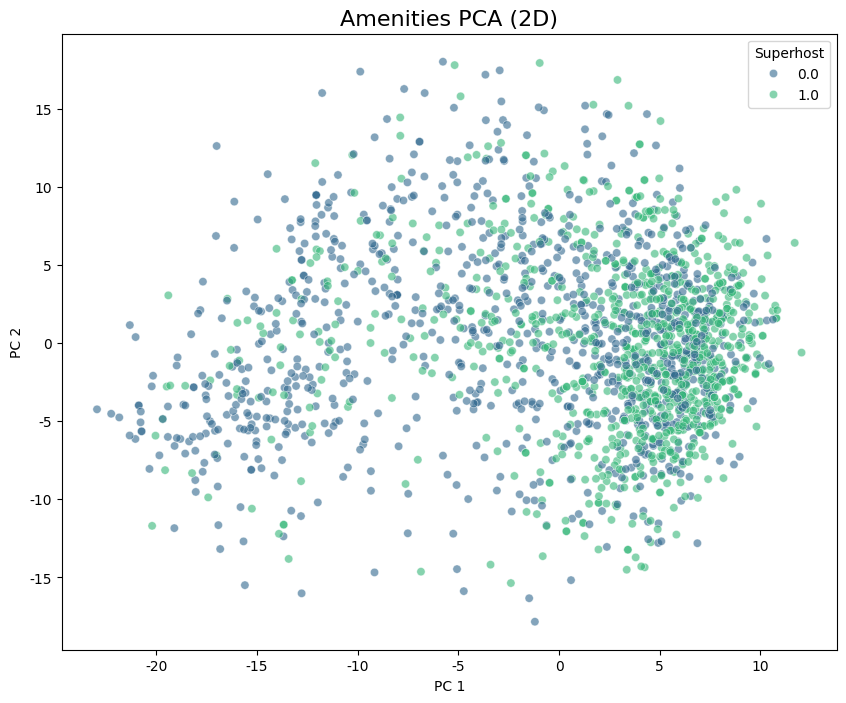

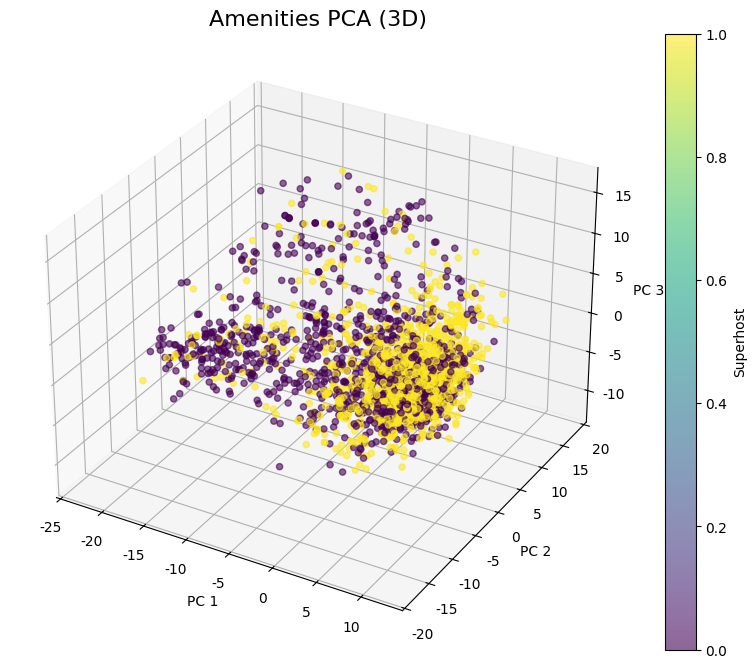

Running t-SNE on Amenities Embeddings...


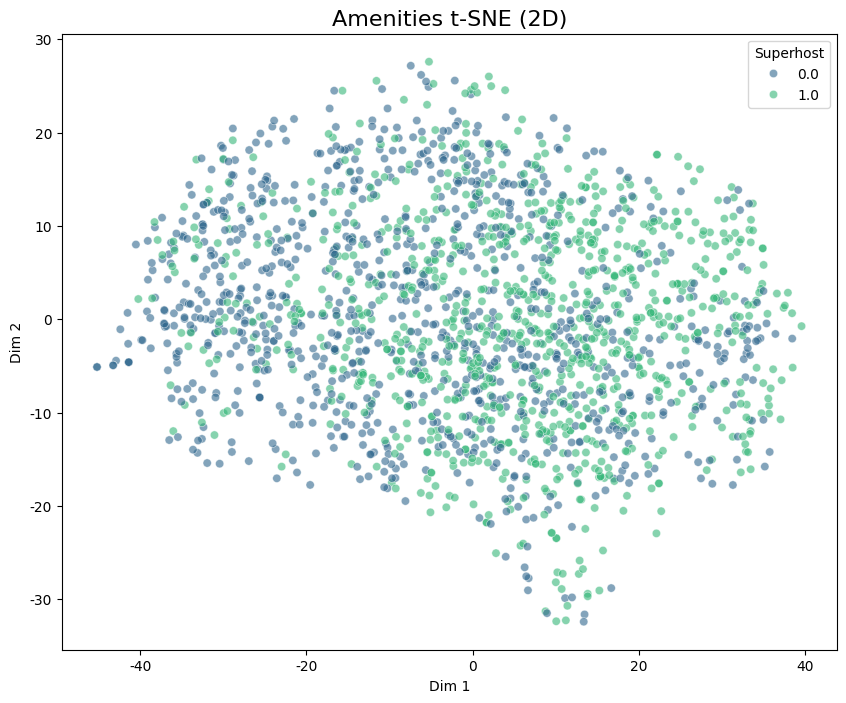

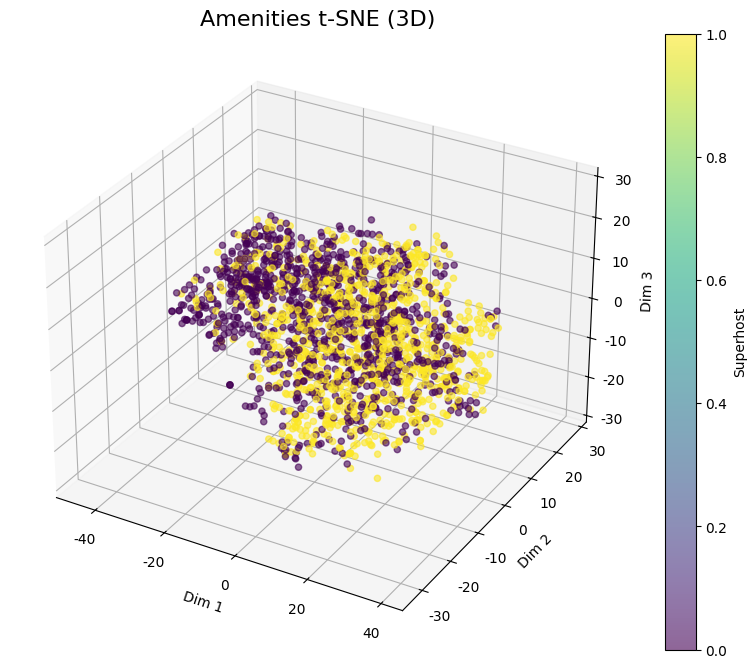

Running UMAP on Amenities Embeddings...


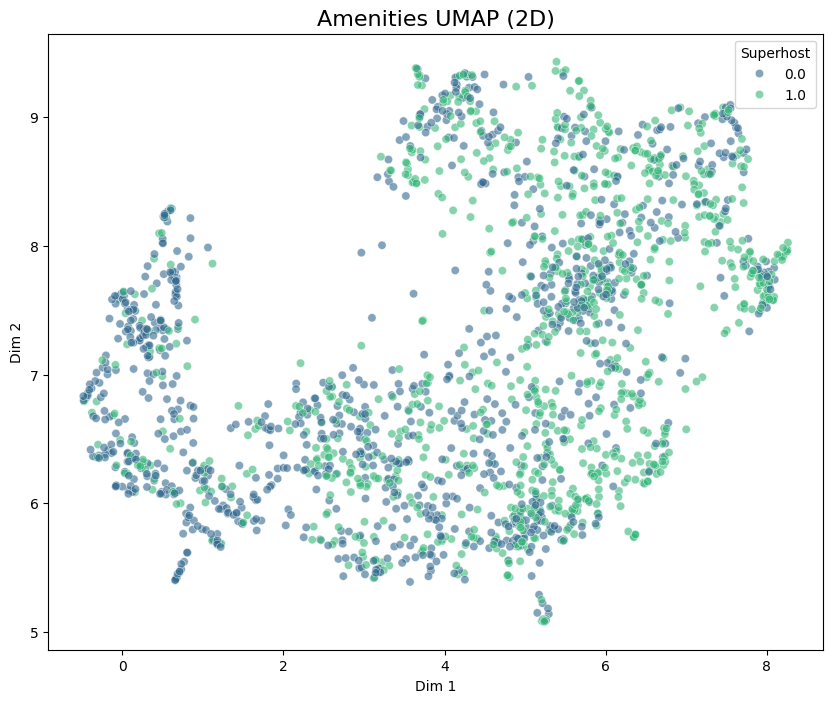

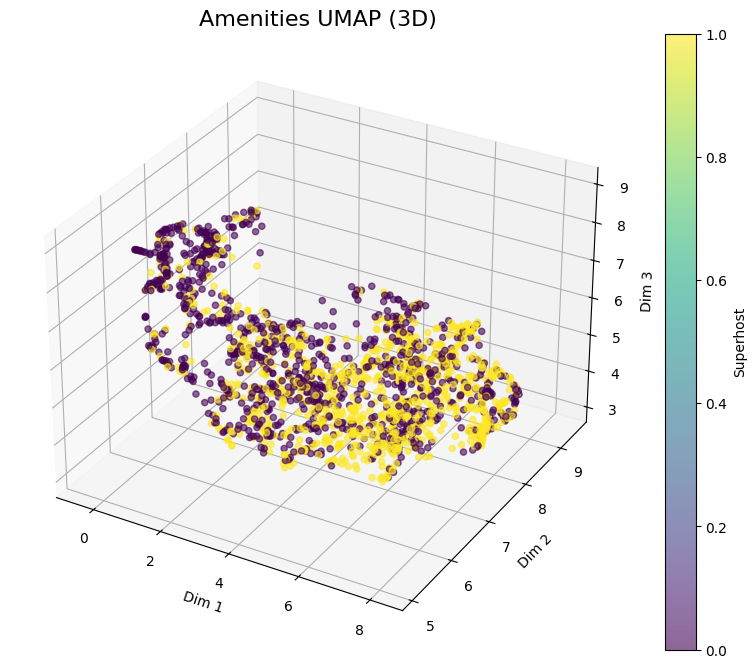

In [66]:
# --- 9. Amenities Embedding Visualization (PCA, t-SNE, UMAP) ---
print("\n--- Amenities Only Embedding Visualization (PCA, t-SNE, UMAP) in 2D & 3D ---")

# NOTE: We strictly select ONLY the columns related to 'amenities' embeddings.
# These columns were created during the preprocessing step with names like 'amenity_emb_0', 'amenity_emb_1', etc.
amenity_cols = [col for col in X_train_balanced.columns if 'amenity_emb_' in col]

if len(amenity_cols) == 0:
    print("Warning: No amenities embedding columns found. Falling back to all columns.")
    X_emb_data = X_train_balanced
else:
    print(f"Correctly selected {len(amenity_cols)} amenities embedding columns for visualization.")
    X_emb_data = X_train_balanced[amenity_cols]

# Sample data for visualization to ensure speed
N_SAMPLES_VIZ = 2000
if len(X_emb_data) > N_SAMPLES_VIZ:
    X_viz, _, y_viz, _ = train_test_split(X_emb_data, y_train_balanced, train_size=N_SAMPLES_VIZ, stratify=y_train_balanced, random_state=42)
else:
    X_viz, y_viz = X_emb_data.copy(), y_train_balanced.copy()

# Standardize the embedding features for better visualization
scaler_viz = StandardScaler()
X_viz_scaled = scaler_viz.fit_transform(X_viz)

def plot_2d(X_emb, y, title, method_name):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=X_emb[:,0], y=X_emb[:,1], hue=y, palette='viridis', alpha=0.6)
    plt.title(f'{title} (2D)', fontsize=16)
    plt.xlabel(f'{method_name} 1')
    plt.ylabel(f'{method_name} 2')
    plt.legend(title='Superhost')
    plt.show()

def plot_3d(X_emb, y, title, method_name):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(X_emb[:,0], X_emb[:,1], X_emb[:,2], c=y, cmap='viridis', s=20, alpha=0.6)
    ax.set_title(f'{title} (3D)', fontsize=16)
    ax.set_xlabel(f'{method_name} 1')
    ax.set_ylabel(f'{method_name} 2')
    ax.set_zlabel(f'{method_name} 3')
    plt.colorbar(sc, label='Superhost')
    plt.show()

# 1. PCA
print("Running PCA on Amenities Embeddings...")
pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_viz_scaled)
plot_2d(pca_result[:, :2], y_viz, "Amenities PCA", "PC")
plot_3d(pca_result, y_viz, "Amenities PCA", "PC")

# 2. t-SNE
print("Running t-SNE on Amenities Embeddings...")
tsne = TSNE(n_components=3, random_state=42, n_jobs=-1)
tsne_result = tsne.fit_transform(X_viz_scaled)
plot_2d(tsne_result[:, :2], y_viz, "Amenities t-SNE", "Dim")
plot_3d(tsne_result, y_viz, "Amenities t-SNE", "Dim")

# 3. UMAP
print("Running UMAP on Amenities Embeddings...")
reducer = umap.UMAP(n_components=3, random_state=42)
umap_result = reducer.fit_transform(X_viz_scaled)
plot_2d(umap_result[:, :2], y_viz, "Amenities UMAP", "Dim")
plot_3d(umap_result, y_viz, "Amenities UMAP", "Dim")



--- Amenities Only Embedding Visualization (PCA, t-SNE, UMAP) in 2D & 3D ---
Correctly selected 384 amenities embedding columns for visualization.
Running PCA on Amenities Embeddings...


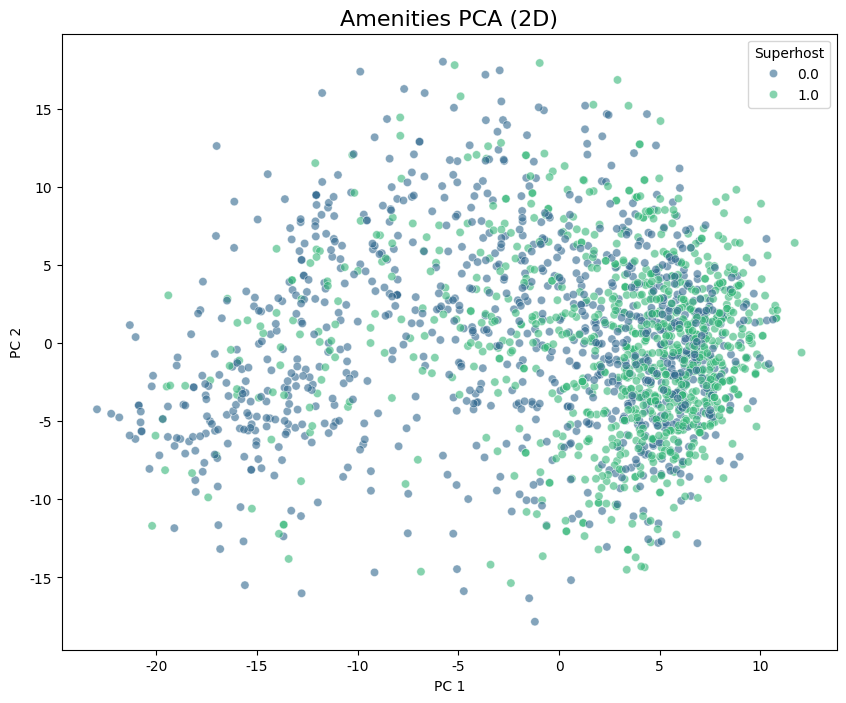

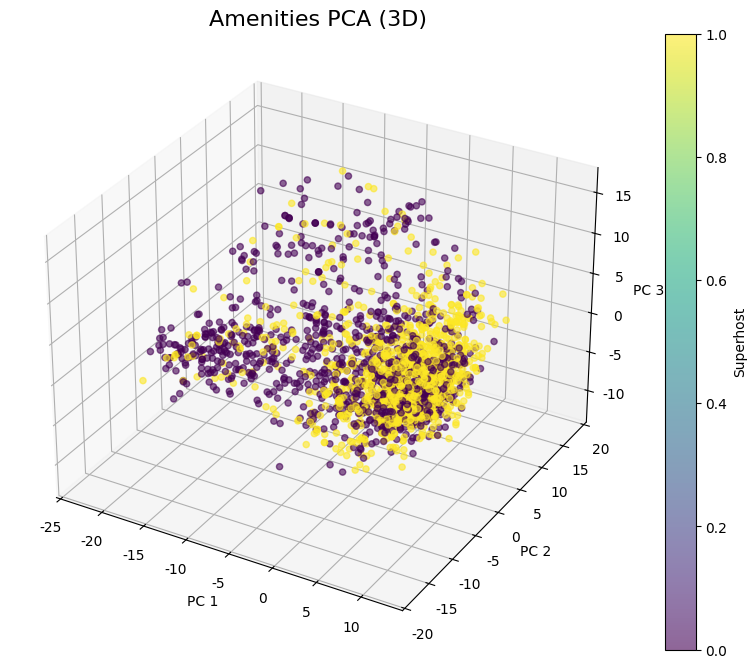

Running t-SNE on Amenities Embeddings...


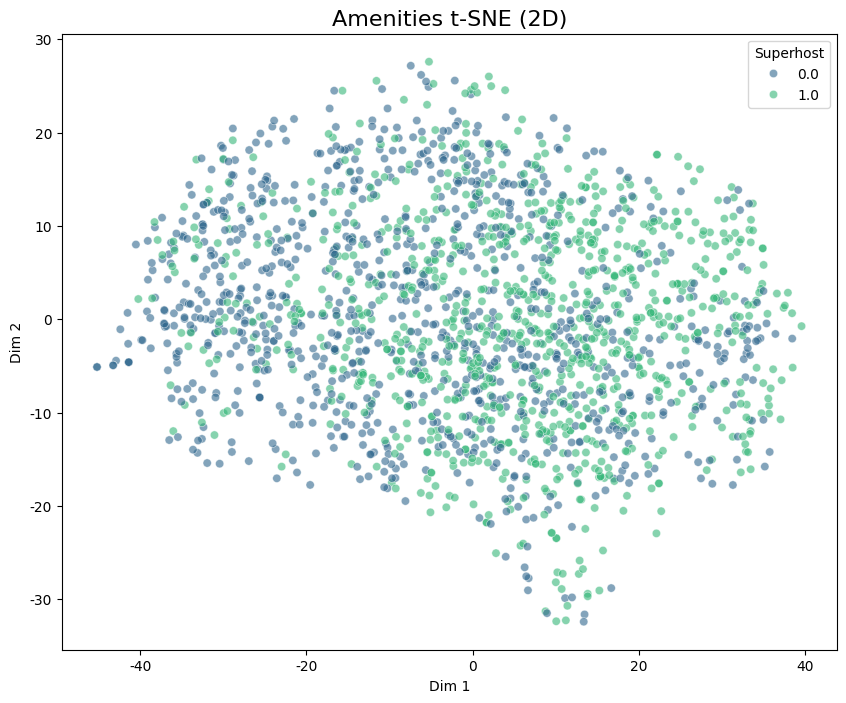

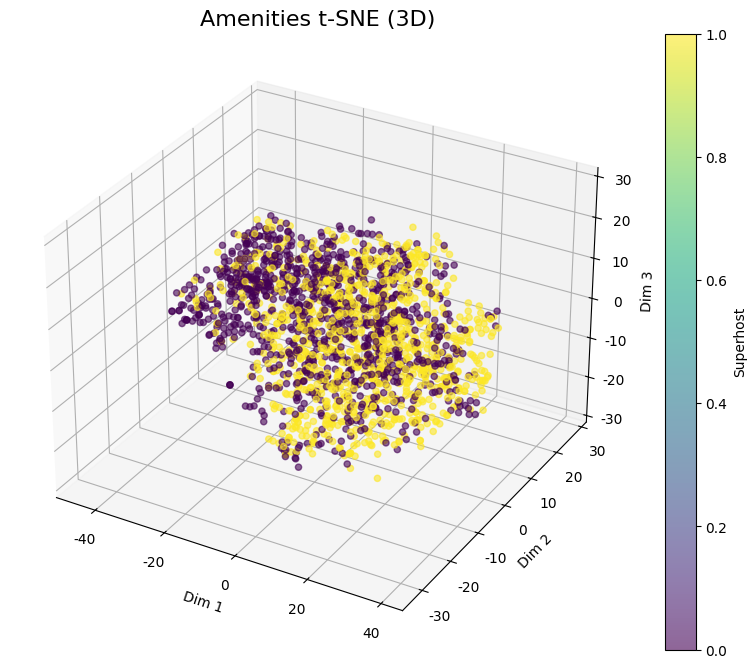

Running UMAP on Amenities Embeddings...


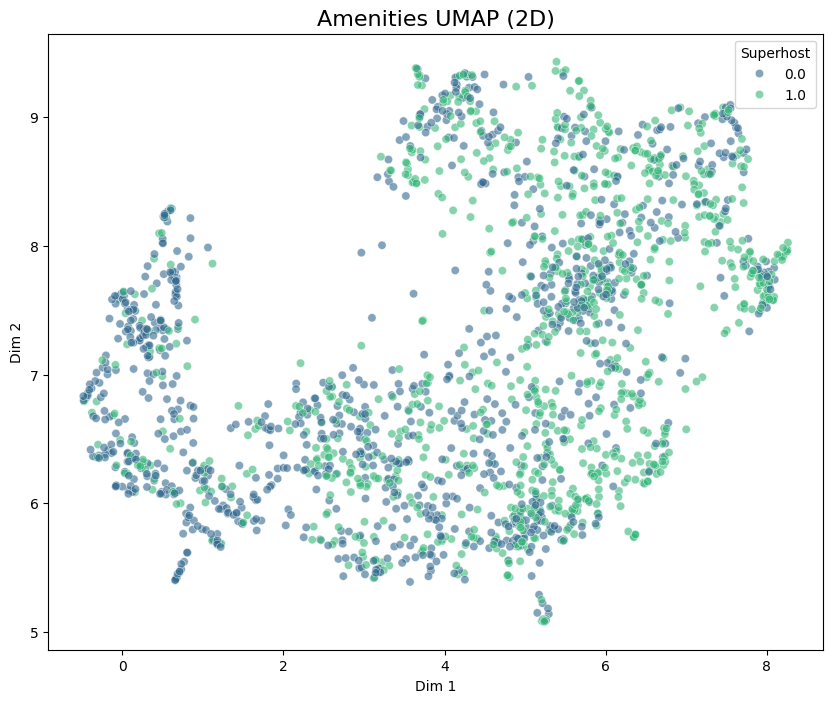

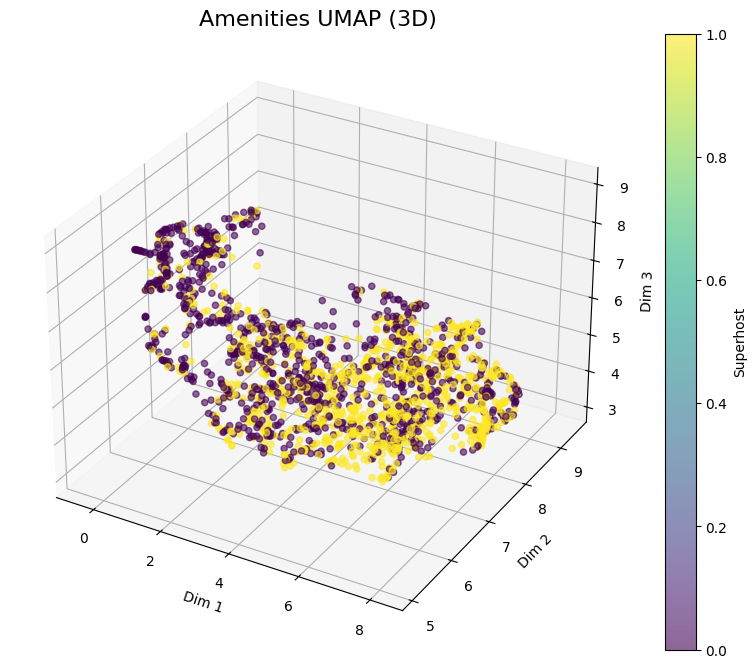

In [67]:
# --- 9. Amenities Embedding Visualization (PCA, t-SNE, UMAP) ---
print("\n--- Amenities Only Embedding Visualization (PCA, t-SNE, UMAP) in 2D & 3D ---")

# NOTE: We strictly select ONLY the columns related to 'amenities' embeddings.
# These columns were created during the preprocessing step with names like 'amenity_emb_0', 'amenity_emb_1', etc.
amenity_cols = [col for col in X_train_balanced.columns if 'amenity_emb_' in col]

if len(amenity_cols) == 0:
    print("Warning: No amenities embedding columns found. Falling back to all columns.")
    X_emb_data = X_train_balanced
else:
    print(f"Correctly selected {len(amenity_cols)} amenities embedding columns for visualization.")
    X_emb_data = X_train_balanced[amenity_cols]

# Sample data for visualization to ensure speed
N_SAMPLES_VIZ = 2000
if len(X_emb_data) > N_SAMPLES_VIZ:
    X_viz, _, y_viz, _ = train_test_split(X_emb_data, y_train_balanced, train_size=N_SAMPLES_VIZ, stratify=y_train_balanced, random_state=42)
else:
    X_viz, y_viz = X_emb_data.copy(), y_train_balanced.copy()

# Standardize the embedding features for better visualization
scaler_viz = StandardScaler()
X_viz_scaled = scaler_viz.fit_transform(X_viz)

def plot_2d(X_emb, y, title, method_name):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=X_emb[:,0], y=X_emb[:,1], hue=y, palette='viridis', alpha=0.6)
    plt.title(f'{title} (2D)', fontsize=16)
    plt.xlabel(f'{method_name} 1')
    plt.ylabel(f'{method_name} 2')
    plt.legend(title='Superhost')
    plt.show()

def plot_3d(X_emb, y, title, method_name):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(X_emb[:,0], X_emb[:,1], X_emb[:,2], c=y, cmap='viridis', s=20, alpha=0.6)
    ax.set_title(f'{title} (3D)', fontsize=16)
    ax.set_xlabel(f'{method_name} 1')
    ax.set_ylabel(f'{method_name} 2')
    ax.set_zlabel(f'{method_name} 3')
    plt.colorbar(sc, label='Superhost')
    plt.show()

# 1. PCA
print("Running PCA on Amenities Embeddings...")
pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_viz_scaled)
plot_2d(pca_result[:, :2], y_viz, "Amenities PCA", "PC")
plot_3d(pca_result, y_viz, "Amenities PCA", "PC")

# 2. t-SNE
print("Running t-SNE on Amenities Embeddings...")
tsne = TSNE(n_components=3, random_state=42, n_jobs=-1)
tsne_result = tsne.fit_transform(X_viz_scaled)
plot_2d(tsne_result[:, :2], y_viz, "Amenities t-SNE", "Dim")
plot_3d(tsne_result, y_viz, "Amenities t-SNE", "Dim")

# 3. UMAP
print("Running UMAP on Amenities Embeddings...")
reducer = umap.UMAP(n_components=3, random_state=42)
umap_result = reducer.fit_transform(X_viz_scaled)
plot_2d(umap_result[:, :2], y_viz, "Amenities UMAP", "Dim")
plot_3d(umap_result, y_viz, "Amenities UMAP", "Dim")


---

In [73]:
# === SAVE & DOWNLOAD RESULTS (Universal: Colab & Local) ===
import os
import shutil
import zipfile
import sys
from datetime import datetime
import glob

# 1. 압축할 폴더 생성 (현재 시간 기준)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
save_dir = f'results_{timestamp}'
os.makedirs(save_dir, exist_ok=True)

print(f"📂 Collecting results into: {save_dir}")

# 2. 결과 파일 수집 (CSV, PNG, SVG)
# 현재 디렉토리에 흩어진 결과 파일들을 모음
file_patterns = ['*.csv', '*.png', '*.svg']
for pattern in file_patterns:
    for file in glob.glob(pattern):
        # 결과 폴더 자체는 제외
        if os.path.isdir(file): continue
        if 'processing' in file: continue # 노트북 파일 제외

        try:
            shutil.copy(file, save_dir)
        except Exception as e:
            pass

# 3. 폴더 압축
zip_filename = f'{save_dir}.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(save_dir):
        for file in files:
            zipf.write(os.path.join(root, file),
                       os.path.relpath(os.path.join(root, file),
                       os.path.join(save_dir, '..')))

print(f"📦 Created archive: {zip_filename}")

# 4. 환경별 다운로드 처리
try:
    # Google Colab 환경 감지
    import google.colab
    print("☁️ Detected Google Colab environment.")
    from google.colab import files
    files.download(zip_filename)
    print("⬇️ Download started!")
except ImportError:
    # 로컬 환경
    print("💻 Detected Local environment.")
    print(f"✅ Results are saved in: {os.path.abspath(zip_filename)}")

    # (선택) 로컬에서 바로 폴더 열기 (Mac/Windows)
    try:
        if sys.platform == 'darwin':  # macOS
            os.system(f'open .')
        elif sys.platform == 'win32': # Windows
            os.system(f'explorer .')
    except:
        pass

📂 Collecting results into: results_20251206_163751
📦 Created archive: results_20251206_163751.zip
☁️ Detected Google Colab environment.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Download started!
